# Fraud Detection as a Cost-Sensitive Decision Problem

**Framing:** the deliverable of a fraud system is not a score — it is a *decision*: block this
transaction or let it through, under asymmetric costs and a latency budget. This notebook is built
around that decision, and treats AUC as diagnostic rather than as the objective.

**Pipeline:** EDA → Imbalance Handling → Cost-Sensitive Thresholding → Time-Based Validation &
Drift → Latency → Explainability → Conclusion

---

### Why the usual version of this project is misleading

The standard treatment of this dataset reports ~0.97 AUC after SMOTE and stops. Three things are
wrong with that as a piece of fraud engineering:

1. **AUC has no threshold.** It integrates over all of them. A model with excellent AUC still
   needs a decision rule, and *that* is where the money is won or lost. Section 5 shows that on the
   *same* model, swapping decision rules moves realised cost by thousands of dollars — and that for
   several models here, the threshold chosen by a standard statistical criterion (Youden's J) costs
   **more than switching the model off entirely**.

2. **Resampling destroys calibration.** SMOTE and class weighting both change the effective base
   rate, which inflates predicted probabilities — here by **45×** and **55×** respectively. If your
   decision rule consumes the probability (and any expected-cost rule does), miscalibrated output
   makes it wrong. Section 4 measures this directly.

3. **One global threshold is provably suboptimal** when the cost of a miss varies per transaction.
   Letting a \$2,000 fraud through costs 100× more than letting a \$20 fraud through, so they
   should not face the same bar. Section 5 derives the per-transaction rule and shows it beats the
   best possible global threshold.

### A note on the features, stated upfront

`V1`–`V28` **arrive already PCA-transformed from the dataset provider** — that anonymization is not
something done in this notebook. Two consequences worth being honest about:

- Applying further PCA would be *additional* dimensionality reduction on top of an existing
  transform, not anonymization. It is not done here: at 30 features with 285k rows there is nothing
  to gain, and it would only further obscure attribution.
- **Explainability is structurally limited.** SHAP can say *which anonymized component* drives
  risk, but no one can map that back to a human-readable reason like "unusual merchant category."
  Section 8 treats this as a real limitation rather than glossing it.

## 0. Setup

In [1]:
# ============================================================================
# Imports and configuration
# ============================================================================
import os
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, brier_score_loss,
)

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ============================================================================
# CONFIG
# ============================================================================
DATA_PATH = os.environ.get("CC_CSV_PATH", "creditcard.csv")

TRAIN_FRAC, VALID_FRAC = 0.60, 0.15      # remainder (25%) is the test fold
COST_FP = 5.0                            # $ friction cost of wrongly blocking a good txn
RECOVERY_RATE = 0.0                      # fraction of a missed fraud recovered via chargeback
LATENCY_BUDGET_MS = 100                  # real-time blocking budget

# Optional dependencies -------------------------------------------------------
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

import sklearn
print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"lightgbm      {lgb.__version__ if HAS_LGB else 'not installed (fallback active)'}")
print(f"imbalanced-learn {'available' if HAS_SMOTE else 'not installed (SMOTE arm skipped)'}")
print(f"shap          {shap.__version__ if HAS_SHAP else 'not installed (fallback active)'}")

numpy 2.4.4 | pandas 3.0.2 | scikit-learn 1.8.0
lightgbm      4.7.0
imbalanced-learn available
shap          0.52.0


## 1. Data

The loader looks for `creditcard.csv` locally, then tries a public mirror, and only falls back to
synthetic data if both fail. **If the fallback fires it prints an unmissable banner** — the numbers
in this notebook are only quotable when the banner says REAL.

Get the file from Kaggle ("Credit Card Fraud Detection", `mlg-ulb/creditcardfraud`) and place it
beside the notebook, or set `CC_CSV_PATH`.

In [2]:
# ============================================================================
# Data loading, with validation and a loudly-flagged synthetic fallback
# ============================================================================
EXPECTED_ROWS, EXPECTED_FRAUD = 284_807, 492
MIRROR_URL = ("https://raw.githubusercontent.com/nsethi31/"
              "Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv")


def validate_dataset(df):
    """Return (ok, reason). Confirms this is the genuine dataset, not a lookalike."""
    need = {"Time", "Amount", "Class"} | {f"V{i}" for i in range(1, 29)}
    missing = need - set(df.columns)
    if missing:
        return False, f"missing columns: {sorted(missing)[:5]}"
    if len(df) < 100_000:
        return False, f"only {len(df):,} rows"
    n_fraud = int(df["Class"].sum())
    if n_fraud == 0:
        return False, "no positive labels"
    if df.isna().sum().sum() > 0:
        return False, f"{int(df.isna().sum().sum())} missing values"
    return True, f"{len(df):,} rows, {n_fraud} frauds ({df['Class'].mean():.4%})"


def make_synthetic(n=EXPECTED_ROWS, n_fraud=EXPECTED_FRAUD, seed=RANDOM_SEED):
    """Emergency fallback ONLY. Shape-compatible, not a substitute for the real data."""
    rng = np.random.default_rng(seed)
    t = np.sort(rng.uniform(0, 172_792, n))
    # diurnal volume pattern + fraud bursts
    V = rng.standard_normal((n, 28))
    y = np.zeros(n, dtype=int)
    burst_centres = rng.uniform(0, 172_792, 12)
    w = np.exp(-((t[:, None] - burst_centres[None, :]) ** 2) / (2 * 2500 ** 2)).sum(axis=1) + 0.25
    y[rng.choice(n, n_fraud, replace=False, p=w / w.sum())] = 1
    signal = [2, 3, 6, 9, 10, 11, 13, 15, 16, 17]      # informative components
    for k, j in enumerate(signal):
        V[y == 1, j] += rng.normal((-1) ** k * 2.2, 1.0, int(y.sum()))
    amt = np.exp(rng.normal(3.0, 1.5, n)).clip(0, 25_000)
    amt[y == 1] = np.exp(rng.normal(3.4, 1.6, int(y.sum()))).clip(0, 25_000)
    cols = {"Time": t}
    cols.update({f"V{i + 1}": V[:, i] for i in range(28)})
    cols.update({"Amount": amt.round(2), "Class": y})
    return pd.DataFrame(cols)


def load_data(path=DATA_PATH):
    if os.path.exists(path):
        df = pd.read_csv(path)
        ok, reason = validate_dataset(df)
        if ok:
            return df, f"REAL — local file '{path}' ({reason})"
        print(f"Local file failed validation ({reason}); trying mirror.")
    else:
        print(f"'{path}' not found; trying public mirror.")

    try:
        df = pd.read_csv(MIRROR_URL)
        ok, reason = validate_dataset(df)
        if ok:
            df.to_csv(path, index=False)
            return df, f"REAL — downloaded mirror, cached to '{path}' ({reason})"
        print(f"Mirror failed validation ({reason}).")
    except Exception as exc:
        print(f"Mirror unavailable ({type(exc).__name__}: {exc}).")

    return make_synthetic(), "SYNTHETIC"


raw, DATA_SOURCE = load_data()
IS_SYNTHETIC = DATA_SOURCE.startswith("SYNTHETIC")

if IS_SYNTHETIC:
    bar = "!" * 84
    print(f"\n{bar}\n{bar}")
    print("!!!                                                                              !!!")
    print("!!!   WARNING: SYNTHETIC DATA IN USE — THE REAL DATASET COULD NOT BE LOADED       !!!")
    print("!!!                                                                              !!!")
    print("!!!   Every number below is FABRICATED and describes a generator, not real        !!!")
    print("!!!   fraud. Do NOT quote any metric, cost figure, or conclusion from this run.    !!!")
    print("!!!   Download creditcard.csv from Kaggle and re-run before using any result.      !!!")
    print("!!!                                                                              !!!")
    print(f"{bar}\n{bar}\n")
else:
    bar = "=" * 84
    print(f"\n{bar}\n  DATA SOURCE: {DATA_SOURCE}\n{bar}")

# Sort chronologically once, here, so every split downstream is time-ordered.
df = raw.sort_values("Time").reset_index(drop=True)
print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Fraud: {int(df['Class'].sum())} of {len(df):,} ({df['Class'].mean():.4%}) "
      f"— roughly 1 in {int(1 / df['Class'].mean()):,}")
print(f"Time spans {df['Time'].max() / 3600:.1f} hours ({df['Time'].max() / 86400:.2f} days)")
df.head(3)


  DATA SOURCE: REAL — local file 'creditcard.csv' (284,807 rows, 492 frauds (0.1727%))
Shape: 284,807 x 31
Fraud: 492 of 284,807 (0.1727%) — roughly 1 in 578
Time spans 48.0 hours (2.00 days)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 2. EDA through a time lens

Most treatments of this dataset plot the class balance, note "0.17%, very imbalanced", and move on.
That misses the structure that actually matters operationally.

**Why time first.** Fraud is not a stationary random draw sprinkled across the dataset. It arrives
in **bursts** — a compromised card number gets tested and drained within minutes, a skimmer dumps a
batch, a bot ring probes a BIN range. That has three concrete implications this notebook builds on:

1. If fraud is bursty, a random train/test split scatters *the same attack* across both folds. The
   model then learns that specific attack in training and is scored on it in test, which is
   leakage. Section 3.
2. Bursts mean the fraud rate in any given hour is far from the global 0.17%, so a fixed threshold
   tuned on the average behaves differently at different times.
3. Burstiness is why fraud models need a **retraining cadence** rather than a one-off fit — new
   attack patterns arrive continuously. Section 7.

`Time` is seconds elapsed since the first transaction, spanning about two days.

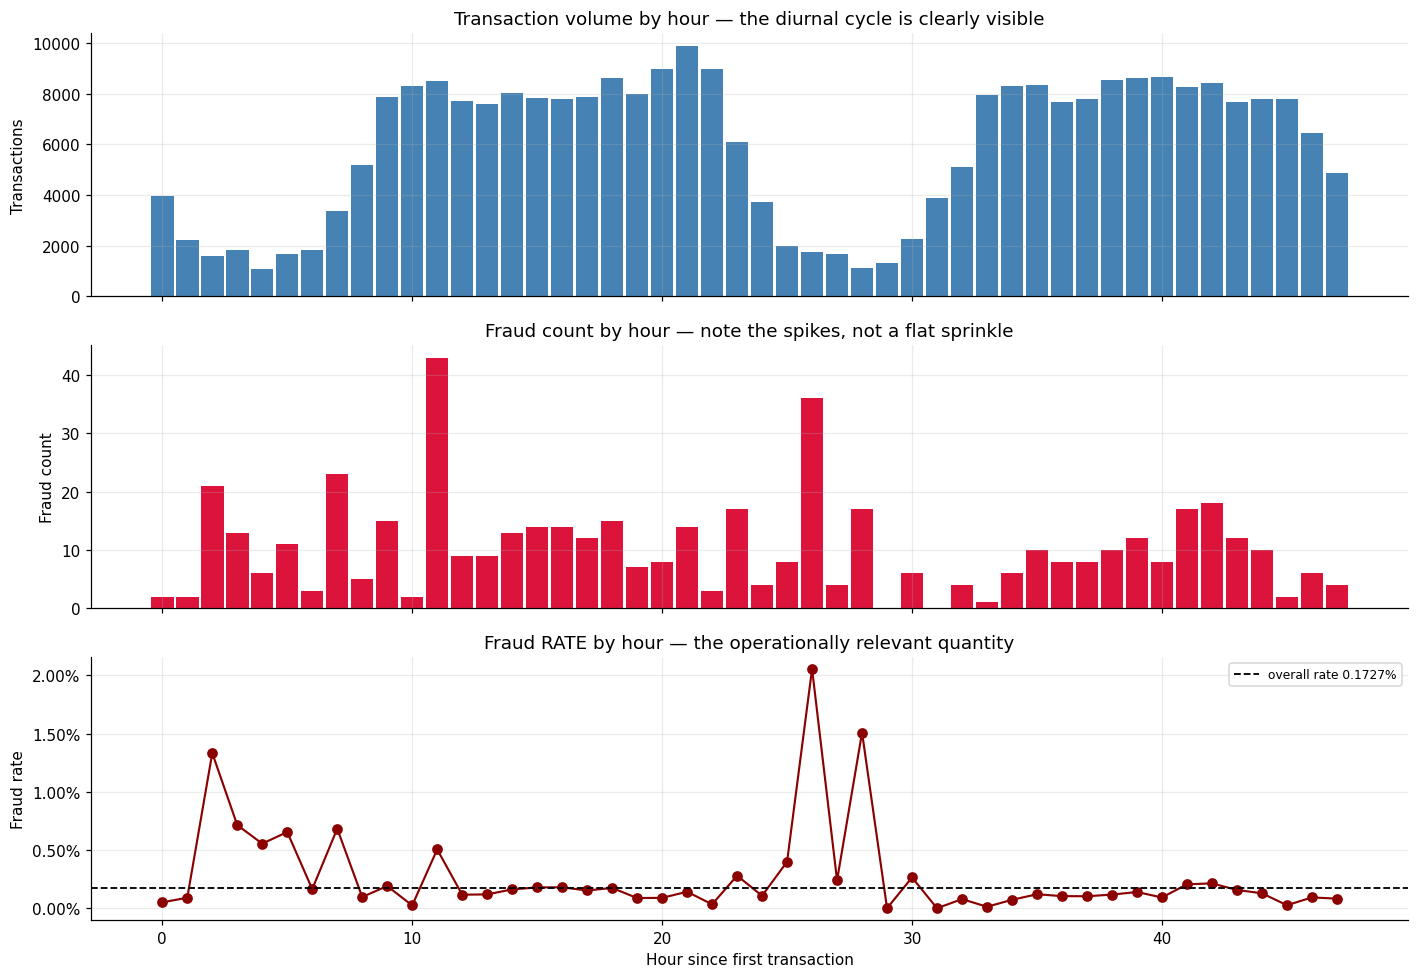

Overall fraud rate      : 0.1727%
Worst hour (hour 26)     : 2.0548% (36 frauds in 1,752 transactions)
Ratio worst hour : overall = 11.9x

Hours with zero fraud   : 2 of 48
A fixed threshold tuned on the average rate is therefore mis-set most of the time — too loose during bursts, too tight during quiet hours.


In [3]:
# ============================================================================
# Volume and fraud rate over time
# ============================================================================
df["hour"] = (df["Time"] // 3600).astype(int)
hourly = df.groupby("hour").agg(n=("Class", "size"), frauds=("Class", "sum"),
                                amount=("Amount", "sum"))
hourly["fraud_rate"] = hourly["frauds"] / hourly["n"]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

axes[0].bar(hourly.index, hourly["n"], color="steelblue", width=0.9)
axes[0].set_ylabel("Transactions")
axes[0].set_title("Transaction volume by hour — the diurnal cycle is clearly visible")

axes[1].bar(hourly.index, hourly["frauds"], color="crimson", width=0.9)
axes[1].set_ylabel("Fraud count")
axes[1].set_title("Fraud count by hour — note the spikes, not a flat sprinkle")

axes[2].plot(hourly.index, hourly["fraud_rate"], "o-", color="darkred", lw=1.4)
axes[2].axhline(df["Class"].mean(), color="k", ls="--", lw=1.2,
                label=f"overall rate {df['Class'].mean():.4%}")
axes[2].set_ylabel("Fraud rate"); axes[2].set_xlabel("Hour since first transaction")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].set_title("Fraud RATE by hour — the operationally relevant quantity")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

peak = hourly["fraud_rate"].idxmax()
print(f"Overall fraud rate      : {df['Class'].mean():.4%}")
print(f"Worst hour (hour {peak:2d})     : {hourly.loc[peak, 'fraud_rate']:.4%} "
      f"({hourly.loc[peak, 'frauds']} frauds in {hourly.loc[peak, 'n']:,} transactions)")
print(f"Ratio worst hour : overall = {hourly.loc[peak, 'fraud_rate'] / df['Class'].mean():.1f}x")
print(f"\nHours with zero fraud   : {int((hourly['frauds'] == 0).sum())} of {len(hourly)}")
print("A fixed threshold tuned on the average rate is therefore mis-set most of the time — "
      "too loose during bursts, too tight during quiet hours.")

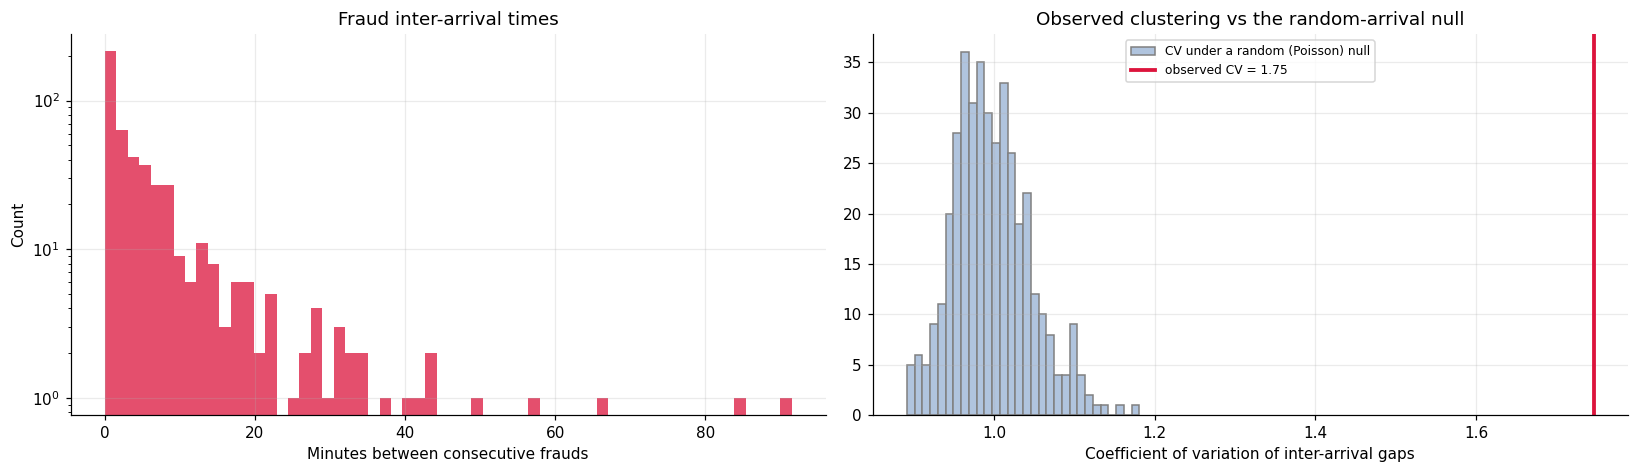

Observed CV of fraud inter-arrival gaps : 1.747
Null (Poisson) CV, mean over 400 draws  : 0.997 [0.910, 1.102]
Fraction of null draws at least as extreme: 0.000%

-> Fraud arrivals are significantly MORE clustered than random. The bursts are real,
   which is exactly why a random train/test split leaks and a time split does not.


In [4]:
# ============================================================================
# Is the burstiness real, or what random arrivals would produce anyway?
# ============================================================================
# Eyeballing spikes is not evidence: rare events look clustered by chance. The
# test is whether inter-arrival times are more dispersed than a Poisson process
# with the same rate. For Poisson, gaps are Exponential and the coefficient of
# variation (sd/mean) is exactly 1. CV > 1 means over-dispersion = real bursts.
fraud_times = df.loc[df["Class"] == 1, "Time"].to_numpy()
gaps = np.diff(fraud_times)
cv = gaps.std() / gaps.mean()

rng = np.random.default_rng(RANDOM_SEED)
null_cv = [np.diff(np.sort(rng.uniform(0, df["Time"].max(), len(fraud_times)))).std() /
           np.diff(np.sort(rng.uniform(0, df["Time"].max(), len(fraud_times)))).mean()
           for _ in range(400)]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
axes[0].hist(gaps / 60, bins=60, color="crimson", alpha=0.75)
axes[0].set_xlabel("Minutes between consecutive frauds"); axes[0].set_ylabel("Count")
axes[0].set_title("Fraud inter-arrival times")
axes[0].set_yscale("log")

axes[1].hist(null_cv, bins=30, color="lightsteelblue", edgecolor="grey",
             label="CV under a random (Poisson) null")
axes[1].axvline(cv, color="crimson", lw=2.5, label=f"observed CV = {cv:.2f}")
axes[1].set_xlabel("Coefficient of variation of inter-arrival gaps")
axes[1].set_title("Observed clustering vs the random-arrival null")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

pct = (np.array(null_cv) >= cv).mean()
print(f"Observed CV of fraud inter-arrival gaps : {cv:.3f}")
print(f"Null (Poisson) CV, mean over 400 draws  : {np.mean(null_cv):.3f} "
      f"[{np.percentile(null_cv, 2.5):.3f}, {np.percentile(null_cv, 97.5):.3f}]")
print(f"Fraction of null draws at least as extreme: {pct:.3%}")
if cv > np.percentile(null_cv, 97.5):
    print("\n-> Fraud arrivals are significantly MORE clustered than random. The bursts are real,")
    print("   which is exactly why a random train/test split leaks and a time split does not.")
else:
    print("\n-> Clustering is not distinguishable from random arrivals at this sample size.")

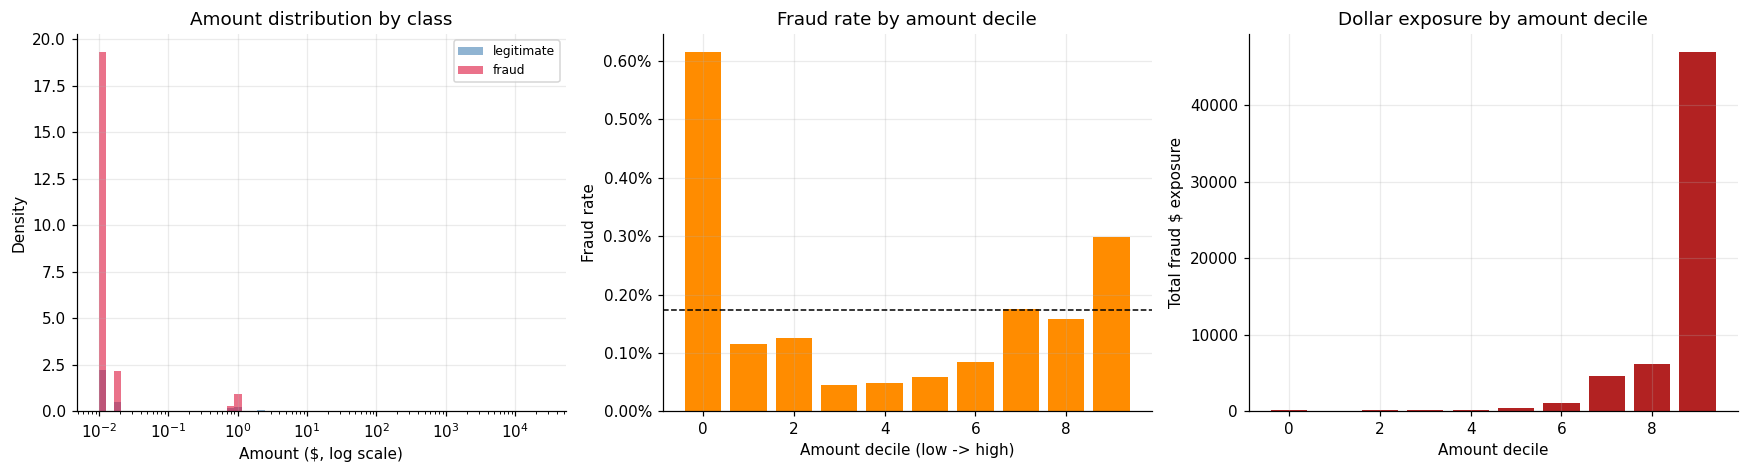

Fraud amounts : median $9.25, mean $122.21, max $2,125.87


Legit amounts : median $22.00, mean $88.29
Total fraud exposure in the dataset: $60,127.97

The largest 10% of frauds account for 61.4% of total fraud dollars.
That concentration is the whole argument for cost-sensitive decisions: counting frauds caught treats a $2 fraud and a $2,000 fraud identically, while the P&L does not.


In [5]:
# ============================================================================
# Amount: the feature that is also the cost driver
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

bins = np.logspace(-2, np.log10(max(df["Amount"].max(), 10)), 60)
axes[0].hist(df.loc[df.Class == 0, "Amount"] + 0.01, bins=bins, alpha=0.6,
             density=True, label="legitimate", color="steelblue")
axes[0].hist(df.loc[df.Class == 1, "Amount"] + 0.01, bins=bins, alpha=0.6,
             density=True, label="fraud", color="crimson")
axes[0].set_xscale("log"); axes[0].set_xlabel("Amount ($, log scale)")
axes[0].set_ylabel("Density"); axes[0].set_title("Amount distribution by class")
axes[0].legend(fontsize=8)

# Fraud rate by amount decile -- does risk vary with ticket size?
df["amt_decile"] = pd.qcut(df["Amount"].rank(method="first"), 10, labels=False)
by_amt = df.groupby("amt_decile").agg(rate=("Class", "mean"), med=("Amount", "median"))
axes[1].bar(by_amt.index, by_amt["rate"], color="darkorange")
axes[1].axhline(df["Class"].mean(), color="k", ls="--", lw=1)
axes[1].set_xlabel("Amount decile (low -> high)"); axes[1].set_ylabel("Fraud rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Fraud rate by amount decile")

# Where does the DOLLAR exposure sit? Not the same as where the counts sit.
expo = df[df.Class == 1].groupby("amt_decile")["Amount"].sum()
axes[2].bar(expo.index, expo.values, color="firebrick")
axes[2].set_xlabel("Amount decile"); axes[2].set_ylabel("Total fraud $ exposure")
axes[2].set_title("Dollar exposure by amount decile")
plt.tight_layout(); plt.show()

fr = df[df.Class == 1]["Amount"]
print(f"Fraud amounts : median ${fr.median():.2f}, mean ${fr.mean():.2f}, max ${fr.max():,.2f}")
print(f"Legit amounts : median ${df[df.Class == 0]['Amount'].median():.2f}, "
      f"mean ${df[df.Class == 0]['Amount'].mean():.2f}")
print(f"Total fraud exposure in the dataset: ${fr.sum():,.2f}")
top10_share = fr.nlargest(max(1, len(fr) // 10)).sum() / fr.sum()
print(f"\nThe largest 10% of frauds account for {top10_share:.1%} of total fraud dollars.")
print("That concentration is the whole argument for cost-sensitive decisions: counting frauds "
      "caught treats a $2 fraud and a $2,000 fraud identically, while the P&L does not.")

## 3. Time-based split

**Why not a random split.** Section 2 established that fraud arrives in bursts. A random split
takes a single burst — one compromised card tested repeatedly, one skimmer's batch — and scatters
those near-identical transactions across train and test. The model memorises the pattern in
training and is graded on near-duplicates of it in test. The resulting score measures *memorisation
of a specific attack*, which is unavailable in production because in production the attack has not
happened yet.

A chronological split reproduces the deployment constraint honestly: train on the past, predict the
future, and never see a pattern before it occurs.

**Three folds, not two:**

| Fold | Share | Purpose |
|---|---|---|
| Train | first 60% | fit model parameters |
| Validation | next 15% | **threshold and calibration fitting** |
| Test | last 25% | untouched until final evaluation |

The validation fold is not optional here. The cost-optimal threshold and the isotonic calibrator
are both *fitted quantities* — choosing them on test would be exactly the leakage this section
exists to prevent, and would make the headline cost number optimistic.

In [6]:
# ============================================================================
# Chronological split
# ============================================================================
FEATURES = [c for c in df.columns if c not in ("Class", "hour", "amt_decile")]

n = len(df)
i_tr, i_va = int(n * TRAIN_FRAC), int(n * (TRAIN_FRAC + VALID_FRAC))

train, valid, test = df.iloc[:i_tr], df.iloc[i_tr:i_va], df.iloc[i_va:]

X_train, y_train = train[FEATURES].to_numpy(), train["Class"].to_numpy()
X_valid, y_valid = valid[FEATURES].to_numpy(), valid["Class"].to_numpy()
X_test, y_test = test[FEATURES].to_numpy(), test["Class"].to_numpy()
amt_valid, amt_test = valid["Amount"].to_numpy(), test["Amount"].to_numpy()

# Scaling: V1-V28 arrive pre-PCA'd and are already roughly standardised, but
# Time and Amount are on completely different scales. Fit on TRAIN only -- the
# scaler is a fitted object and must not see validation or test.
scaler = StandardScaler().fit(X_train)
Xs_train, Xs_valid, Xs_test = (scaler.transform(X_train), scaler.transform(X_valid),
                               scaler.transform(X_test))

split_tbl = pd.DataFrame([
    {"fold": "train", "n": len(train), "frauds": int(y_train.sum()),
     "rate": y_train.mean(), "hours": f"{train.Time.min()/3600:.1f}–{train.Time.max()/3600:.1f}",
     "fraud $": train.loc[train.Class == 1, "Amount"].sum()},
    {"fold": "valid", "n": len(valid), "frauds": int(y_valid.sum()),
     "rate": y_valid.mean(), "hours": f"{valid.Time.min()/3600:.1f}–{valid.Time.max()/3600:.1f}",
     "fraud $": valid.loc[valid.Class == 1, "Amount"].sum()},
    {"fold": "test", "n": len(test), "frauds": int(y_test.sum()),
     "rate": y_test.mean(), "hours": f"{test.Time.min()/3600:.1f}–{test.Time.max()/3600:.1f}",
     "fraud $": test.loc[test.Class == 1, "Amount"].sum()},
]).set_index("fold")
display(split_tbl.style.format({"n": "{:,}", "rate": "{:.4%}", "fraud $": "${:,.0f}"}))

assert y_train.sum() > 0 and y_valid.sum() > 0 and y_test.sum() > 0, "a fold has no frauds"
print(f"Train fraud rate {y_train.mean():.4%} vs test {y_test.mean():.4%} "
      f"({y_test.mean() / y_train.mean():.2f}x)")
print(f"\nOnly {int(y_train.sum())} fraud examples to learn from. That -- not the 285k rows -- is")
print("the real sample size, and it is why heavily parameterised models overfit here.")

,n,frauds,rate,hours,fraud $
fold,,,,,
train,"170,884",360,0.2107%,0.0–33.4,"$40,168"
valid,"42,721",38,0.0889%,33.4–38.7,"$9,121"
test,"71,202",94,0.1320%,38.7–48.0,"$10,839"


Train fraud rate 0.2107% vs test 0.1320% (0.63x)

Only 360 fraud examples to learn from. That -- not the 285k rows -- is
the real sample size, and it is why heavily parameterised models overfit here.


## 4. Imbalance handling — three framings compared

Three genuinely different approaches, not three flavours of the same one:

**(a) Class-weighted loss.** Keep every row, reweight the loss so the 0.17% minority carries
comparable total weight. No synthetic data, no discarded rows.

**(b) SMOTE oversampling.** Synthesise new minority examples by interpolating between a fraud and
its nearest fraud neighbours. The standard recipe in write-ups of this dataset. Worth noting the
assumption it makes: that the segment joining two frauds in feature space is itself fraudulent.
With 30 pre-PCA'd dimensions and ~360 training frauds, those neighbours can be far apart, and the
interpolated points may lie in regions no real fraud occupies.

**(c) Anomaly detection.** Fit Isolation Forest on **legitimate transactions only** and score fraud
as "unlike normal." This discards the labels entirely, which sounds wasteful — and is, when labels
exist. Its real value is catching *novel* attack types that no labelled example covers. Included
here to quantify the trade-off rather than assume it.

Each is paired with a matched classifier so the comparison isolates the imbalance treatment.

> **What to watch for:** the interesting result is not which arm wins on AUC. It is what each one
> does to the *calibration* of the output probabilities, measured immediately after.

In [7]:
# ============================================================================
# Train the three arms (plus an unweighted control)
# ============================================================================
def make_gbm(**kw):
    """LightGBM if available, else a sklearn HistGradientBoosting fallback."""
    if HAS_LGB:
        params = dict(n_estimators=300, learning_rate=0.05, num_leaves=7,
                      min_child_samples=50, subsample=0.8, subsample_freq=1,
                      colsample_bytree=0.8, reg_lambda=1.0, verbose=-1,
                      random_state=RANDOM_SEED, n_jobs=-1)
        params.update(kw)
        return lgb.LGBMClassifier(**params)
    from sklearn.ensemble import HistGradientBoostingClassifier
    return HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                          max_leaf_nodes=7, min_samples_leaf=50,
                                          random_state=RANDOM_SEED)


models, timings = {}, {}

# --- control: no imbalance handling at all ---------------------------------
t0 = time.perf_counter()
models["GBM (no handling)"] = make_gbm().fit(Xs_train, y_train)
timings["GBM (no handling)"] = time.perf_counter() - t0

# --- (a) class-weighted -----------------------------------------------------
t0 = time.perf_counter()
models["LR (class-weighted)"] = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED).fit(Xs_train, y_train)
timings["LR (class-weighted)"] = time.perf_counter() - t0

t0 = time.perf_counter()
models["RF (class-weighted)"] = RandomForestClassifier(
    n_estimators=100, min_samples_leaf=5, class_weight="balanced_subsample",
    random_state=RANDOM_SEED, n_jobs=-1).fit(Xs_train, y_train)
timings["RF (class-weighted)"] = time.perf_counter() - t0

# --- (b) SMOTE --------------------------------------------------------------
if HAS_SMOTE:
    t0 = time.perf_counter()
    # k_neighbors must be < the number of minority samples available.
    sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=min(5, int(y_train.sum()) - 1))
    Xr, yr = sm.fit_resample(Xs_train, y_train)
    models["LR (SMOTE)"] = LogisticRegression(max_iter=1000,
                                              random_state=RANDOM_SEED).fit(Xr, yr)
    timings["LR (SMOTE)"] = time.perf_counter() - t0
    print(f"SMOTE resampled {len(y_train):,} -> {len(yr):,} rows "
          f"(fraud rate {y_train.mean():.4%} -> {yr.mean():.1%})")

    t0 = time.perf_counter()
    models["GBM (SMOTE)"] = make_gbm().fit(Xr, yr)
    timings["GBM (SMOTE)"] = time.perf_counter() - t0
else:
    print("imbalanced-learn not installed — SMOTE arm skipped.")

# --- (c) anomaly detection, fit on legitimate transactions ONLY -------------
t0 = time.perf_counter()
iso = IsolationForest(n_estimators=150, contamination=0.002, max_samples=50_000,
                      random_state=RANDOM_SEED, n_jobs=-1).fit(Xs_train[y_train == 0])
timings["IsolationForest (unsupervised)"] = time.perf_counter() - t0
models["IsolationForest (unsupervised)"] = iso

# --- a small neural net, for the latency comparison later ------------------
t0 = time.perf_counter()
models["MLP (class-weighted via resample)"] = MLPClassifier(
    hidden_layer_sizes=(32, 16), max_iter=60, random_state=RANDOM_SEED,
    early_stopping=True, n_iter_no_change=8).fit(
        *(sm.fit_resample(Xs_train, y_train) if HAS_SMOTE else (Xs_train, y_train)))
timings["MLP (class-weighted via resample)"] = time.perf_counter() - t0

print(f"\nTrained {len(models)} models.")
for k, v in timings.items():
    print(f"  {k:36s} {v:7.1f}s")

SMOTE resampled 170,884 -> 341,048 rows (fraud rate 0.2107% -> 50.0%)



Trained 7 models.
  GBM (no handling)                        5.3s
  LR (class-weighted)                      0.5s
  RF (class-weighted)                     69.8s
  LR (SMOTE)                               1.3s
  GBM (SMOTE)                              9.9s
  IsolationForest (unsupervised)           3.5s
  MLP (class-weighted via resample)        8.0s


In [8]:
# ============================================================================
# Score every model on validation and test
# ============================================================================
def score_model(model, X):
    """Uniform scoring interface. IsolationForest has no predict_proba, so its
    anomaly score is min-max mapped to [0,1] -- a monotone transform, so ranking
    metrics (AUC, PR-AUC) are unaffected, but the result is NOT a probability
    and must not be fed to an expected-cost rule."""
    if isinstance(model, IsolationForest):
        s = -model.score_samples(X)
        return (s - s.min()) / (s.max() - s.min() + 1e-12)
    return model.predict_proba(X)[:, 1]


scores_valid = {k: score_model(m, Xs_valid) for k, m in models.items()}
scores_test = {k: score_model(m, Xs_test) for k, m in models.items()}

rows = []
for k in models:
    pv, pt = scores_valid[k], scores_test[k]
    rows.append({
        "model": k,
        "AUC-ROC": roc_auc_score(y_test, pt),
        "PR-AUC": average_precision_score(y_test, pt),
        "PR-AUC lift": average_precision_score(y_test, pt) / y_test.mean(),
        "Brier": brier_score_loss(y_test, pt),
        "mean pred": pt.mean(),
        "calib ratio": pt.mean() / y_test.mean(),
    })
perf = pd.DataFrame(rows).set_index("model").sort_values("PR-AUC", ascending=False)
display(perf.style.format({
    "AUC-ROC": "{:.4f}", "PR-AUC": "{:.4f}", "PR-AUC lift": "{:.0f}x",
    "Brier": "{:.6f}", "mean pred": "{:.5f}", "calib ratio": "{:.1f}x",
}).background_gradient(cmap="RdYlGn", subset=["PR-AUC"]))

print(f"Test fraud rate (a random model's PR-AUC): {y_test.mean():.5f}")
print("\nRead PR-AUC, not AUC-ROC. At a 0.13% base rate, ROC's false-positive-rate axis is")
print("dominated by the 99.87% majority: a model can look excellent on AUC while flagging")
print("hundreds of good customers per fraud caught. Isolation Forest below is the clean")
print("illustration of exactly that failure.")

,AUC-ROC,PR-AUC,PR-AUC lift,Brier,mean pred,calib ratio
model,,,,,,
RF (class-weighted),0.9354,0.8080,612x,0.000451,0.00234,1.8x
GBM (SMOTE),0.9721,0.7913,599x,0.000792,0.00502,3.8x
MLP (class-weighted via resample),0.9743,0.7664,580x,0.000541,0.00093,0.7x
LR (SMOTE),0.9762,0.7592,575x,0.020287,0.06005,45.5x
GBM (no handling),0.9766,0.7547,572x,0.000545,0.00100,0.8x
LR (class-weighted),0.9780,0.7535,571x,0.023437,0.07207,54.6x
IsolationForest (unsupervised),0.9451,0.1007,76x,0.004941,0.04613,34.9x


Test fraud rate (a random model's PR-AUC): 0.00132

Read PR-AUC, not AUC-ROC. At a 0.13% base rate, ROC's false-positive-rate axis is
dominated by the 99.87% majority: a model can look excellent on AUC while flagging
hundreds of good customers per fraud caught. Isolation Forest below is the clean
illustration of exactly that failure.


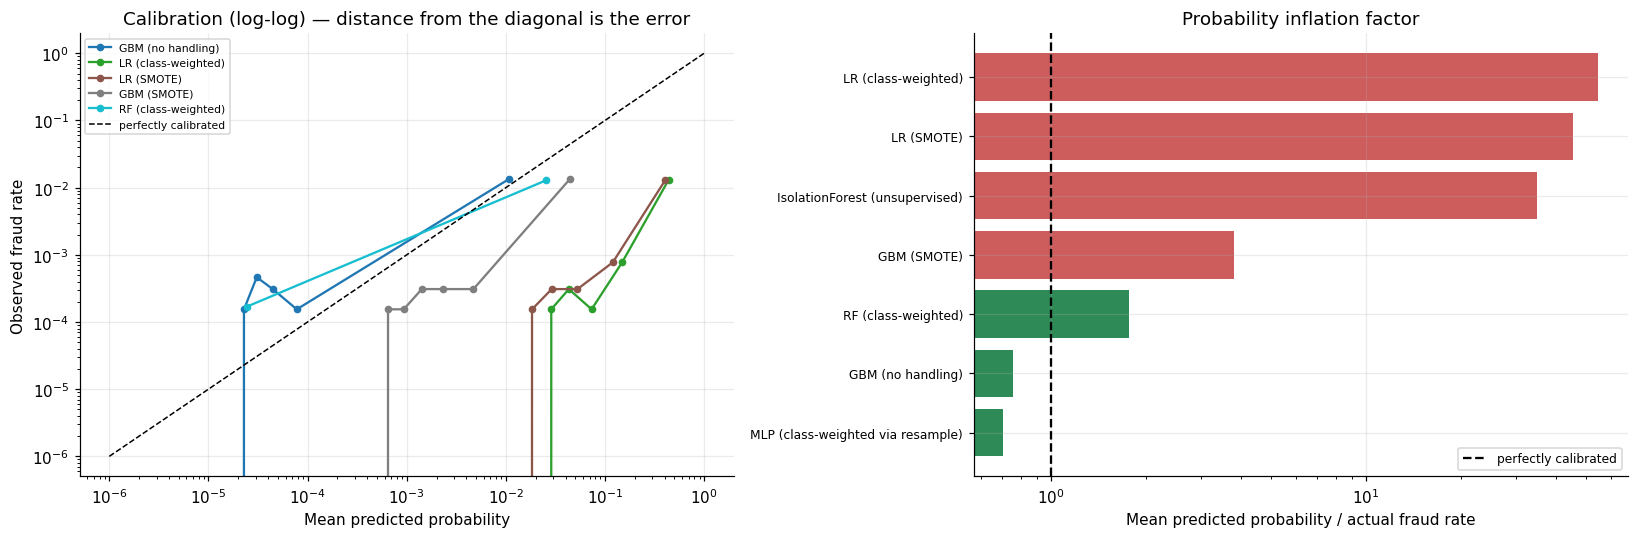

  GBM (no handling)          inflation    0.8x   usable as a probability
  LR (class-weighted)        inflation   54.6x   NOT a probability — inflated
  LR (SMOTE)                 inflation   45.5x   NOT a probability — inflated
  GBM (SMOTE)                inflation    3.8x   NOT a probability — inflated
  RF (class-weighted)        inflation    1.8x   usable as a probability

Class weighting and SMOTE both inflate predicted probabilities by more than an order of
magnitude, because both change the effective base rate the model is fit against. AUC is
untouched (it only depends on ranking), which is precisely why this defect is invisible
to the standard version of this project — and fatal to a cost-based decision rule.

Fix: recalibrate on the validation fold (section 5). Isotonic regression is monotone,
so it repairs the probability scale without disturbing the ranking or the AUC.


In [9]:
# ============================================================================
# The finding that matters: what imbalance handling does to CALIBRATION
# ============================================================================
# A cost-sensitive rule computes expected cost = p * Amount, so it consumes the
# PROBABILITY, not the ranking. Any method that shifts the effective base rate
# breaks that number even while improving AUC.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

show = [k for k in ["GBM (no handling)", "LR (class-weighted)", "LR (SMOTE)",
                    "GBM (SMOTE)", "RF (class-weighted)"] if k in models]
colors = plt.cm.tab10(np.linspace(0, 1, len(show)))

for k, c in zip(show, colors):
    pt = scores_test[k]
    # Quantile bins keep every bin populated at this base rate.
    edges = np.unique(np.quantile(pt, np.linspace(0, 1, 12)))
    if len(edges) < 3:
        continue
    idx = np.clip(np.digitize(pt, edges[1:-1], right=True), 0, len(edges) - 2)
    xs, ys = [], []
    for b in range(len(edges) - 1):
        m = idx == b
        if m.sum() > 50:
            xs.append(pt[m].mean()); ys.append(y_test[m].mean())
    axes[0].plot(xs, ys, "o-", color=c, label=k, lw=1.5, ms=4)

lim = [1e-6, 1]
axes[0].plot(lim, lim, "k--", lw=1, label="perfectly calibrated")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Mean predicted probability"); axes[0].set_ylabel("Observed fraud rate")
axes[0].set_title("Calibration (log-log) — distance from the diagonal is the error")
axes[0].legend(fontsize=7)

ratios = perf["calib ratio"].sort_values()
axes[1].barh(range(len(ratios)), ratios.values,
             color=["seagreen" if v < 3 else "indianred" for v in ratios.values])
axes[1].axvline(1.0, color="k", ls="--", lw=1.5, label="perfectly calibrated")
axes[1].set_yticks(range(len(ratios)), ratios.index, fontsize=8)
axes[1].set_xscale("log")
axes[1].set_xlabel("Mean predicted probability / actual fraud rate")
axes[1].set_title("Probability inflation factor")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for k in show:
    r = perf.loc[k, "calib ratio"]
    verdict = "usable as a probability" if r < 3 else "NOT a probability — inflated"
    print(f"  {k:26s} inflation {r:6.1f}x   {verdict}")

print("\nClass weighting and SMOTE both inflate predicted probabilities by more than an order of")
print("magnitude, because both change the effective base rate the model is fit against. AUC is")
print("untouched (it only depends on ranking), which is precisely why this defect is invisible")
print("to the standard version of this project — and fatal to a cost-based decision rule.")
print("\nFix: recalibrate on the validation fold (section 5). Isotonic regression is monotone,")
print("so it repairs the probability scale without disturbing the ranking or the AUC.")

## 5. Cost-sensitive decisions

### 5.1 The cost matrix

| | Predicted legitimate | Predicted fraud (blocked) |
|---|---|---|
| **Actually legitimate** | \$0 | **\$5** — customer friction, support call, abandoned purchase |
| **Actually fraud** | **full transaction amount** | \$0 — loss prevented |

The asymmetry is the entire point: a false negative costs a *variable* amount that can run to
thousands, a false positive costs a *fixed* small amount. Nothing about optimising F1 or AUC
encodes that.

`RECOVERY_RATE` is exposed as a parameter because in reality a missed fraud is not always a total
loss — some is clawed back through chargebacks, at the cost of an operations process. Set to 0 here
for the clean case; raising it shrinks the value of catching fraud and pushes the optimal threshold
up.

### 5.2 Why a single global threshold is the wrong shape of answer

For one transaction with fraud probability $p$ and amount $A$:

$$\mathbb{E}[\text{cost} \mid \text{allow}] = p \cdot A, \qquad
\mathbb{E}[\text{cost} \mid \text{block}] = (1-p) \cdot C_{FP}$$

Block when blocking is cheaper:

$$p \cdot A > (1-p) \cdot C_{FP}
\quad\Longleftrightarrow\quad
\boxed{\;p > \frac{C_{FP}}{C_{FP} + A}\;}$$

**The optimal threshold is a function of the transaction amount, not a constant.** With
$C_{FP} = \$5$:

| Amount | Optimal threshold |
|---|---|
| \$10 | 0.333 |
| \$100 | 0.048 |
| \$1,000 | 0.005 |
| \$5,000 | 0.001 |

A \$5,000 transaction should be blocked on one-tenth of one percent suspicion; a \$10 transaction
needs 33% before blocking is worth the friction. Any single global threshold is a compromise
between these, and is therefore wrong for nearly every transaction.

**This rule requires calibrated $p$** — which is exactly why section 4's calibration finding is
load-bearing rather than a side observation. Feed it a 45×-inflated SMOTE probability and it blocks
almost everything.

In [10]:
# ============================================================================
# Cost machinery
# ============================================================================

def total_cost(y_true, blocked, amounts, cost_fp=COST_FP, recovery=RECOVERY_RATE):
    """Realised dollar cost of a set of block/allow decisions.

    FN: fraud allowed through -> lose the amount, less anything recovered.
    FP: legitimate blocked    -> fixed friction cost.
    TP/TN: no cost.
    """
    fn = (y_true == 1) & (blocked == 0)
    fp = (y_true == 0) & (blocked == 1)
    return float((amounts[fn].sum() * (1 - recovery)) + fp.sum() * cost_fp)


def cost_curve(y_true, scores, amounts, thresholds):
    return np.array([total_cost(y_true, (scores >= t).astype(int), amounts)
                     for t in thresholds])


def best_global_threshold(y_true, scores, amounts, n_grid=600):
    """Threshold minimising realised cost. Candidates include score quantiles so
    the grid is dense where the scores actually live."""
    grid = np.unique(np.concatenate([
        np.linspace(0, 1, n_grid),
        np.quantile(scores, np.linspace(0, 1, n_grid)),
    ]))
    costs = cost_curve(y_true, scores, amounts, grid)
    return float(grid[int(np.argmin(costs))]), float(costs.min())


# ---- reference points ------------------------------------------------------
cost_never = total_cost(y_test, np.zeros_like(y_test), amt_test)
cost_always = total_cost(y_test, np.ones_like(y_test), amt_test)
cost_oracle = total_cost(y_test, y_test, amt_test)

print(f"Test fold: {len(y_test):,} transactions, {int(y_test.sum())} frauds, "
      f"${amt_test[y_test == 1].sum():,.0f} of fraud exposure\n")
print(f"  Never block anything : ${cost_never:>10,.0f}   <- the do-nothing baseline")
print(f"  Block everything     : ${cost_always:>10,.0f}")
print(f"  Perfect oracle       : ${cost_oracle:>10,.0f}")
print("\nAny model must beat the do-nothing baseline to be worth deploying at all. That is a")
print("lower bar than it sounds, and one of the thresholds below fails it.")

Test fold: 71,202 transactions, 94 frauds, $10,839 of fraud exposure

  Never block anything : $    10,839   <- the do-nothing baseline
  Block everything     : $   355,540
  Perfect oracle       : $         0

Any model must beat the do-nothing baseline to be worth deploying at all. That is a
lower bar than it sounds, and one of the thresholds below fails it.


In [11]:
# ============================================================================
# Threshold selection: statistical criteria vs cost criterion
# ============================================================================
# Every threshold is chosen on VALIDATION, then applied unchanged to TEST.
BEST_MODEL = perf.index[0]
pv, pt = scores_valid[BEST_MODEL], scores_test[BEST_MODEL]
print(f"Model: {BEST_MODEL}\n")

# --- calibrate on validation (monotone -> ranking and AUC unchanged) --------
iso_cal = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(pv, y_valid)
pv_cal, pt_cal = iso_cal.predict(pv), iso_cal.predict(pt)
print(f"Calibration: mean predicted {pt.mean():.5f} -> {pt_cal.mean():.5f} "
      f"(actual {y_test.mean():.5f})")
print(f"AUC before {roc_auc_score(y_test, pt):.4f} / after {roc_auc_score(y_test, pt_cal):.4f} "
      f"— unchanged, as isotonic is monotone\n")

# --- candidate thresholds, all fitted on validation ------------------------
fpr, tpr, thr_roc = roc_curve(y_valid, pv)
t_youden = float(thr_roc[np.argmax(tpr - fpr)])

prec, rec, thr_pr = precision_recall_curve(y_valid, pv)
f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
t_f1 = float(thr_pr[min(int(np.argmax(f1)), len(thr_pr) - 1)])

t_cost, _ = best_global_threshold(y_valid, pv, amt_valid)

strategies = {
    "Youden's J (max TPR-FPR)": (pt >= t_youden).astype(int),
    "Max F1": (pt >= t_f1).astype(int),
    "Cost-optimal global threshold": (pt >= t_cost).astype(int),
    "Cost-optimal PER-TRANSACTION": (pt_cal >= COST_FP / (COST_FP + amt_test)).astype(int),
}

rows = []
for name, blocked in strategies.items():
    tn, fp_, fn_, tp = confusion_matrix(y_test, blocked, labels=[0, 1]).ravel()
    c = total_cost(y_test, blocked, amt_test)
    rows.append({
        "strategy": name, "blocked": int(blocked.sum()),
        "frauds caught": int(tp), "frauds missed": int(fn_),
        "good blocked": int(fp_),
        "recall": tp / max(tp + fn_, 1), "precision": tp / max(tp + fp_, 1),
        "$ cost": c, "vs do-nothing": c - cost_never,
    })
strat = pd.DataFrame(rows).set_index("strategy")
display(strat.style.format({
    "blocked": "{:,}", "recall": "{:.1%}", "precision": "{:.1%}",
    "$ cost": "${:,.0f}", "vs do-nothing": "${:+,.0f}"}).background_gradient(
    cmap="RdYlGn_r", subset=["$ cost"]))

best_s, worst_s = strat["$ cost"].idxmin(), strat["$ cost"].idxmax()
print(f"Cheapest: {best_s} at ${strat.loc[best_s, '$ cost']:,.0f}")
print(f"Costliest: {worst_s} at ${strat.loc[worst_s, '$ cost']:,.0f}")
print(f"\nSpread between threshold choices on the SAME model: "
      f"${strat['$ cost'].max() - strat['$ cost'].min():,.0f}")
print("Same predictions, same AUC — only the decision rule differs. The threshold is not a")
print("post-processing detail, it is where most of the realised value sits.")

failing = strat[strat["vs do-nothing"] > 0]
if len(failing):
    for nm, r in failing.iterrows():
        print(f"\n  ! '{nm}' costs ${r['vs do-nothing']:+,.0f} MORE than never blocking at all.")
    print("    It maximises a statistical criterion that assigns equal weight to every error,")
    print("    so it buys recall by blocking good customers whose friction cost exceeds the")
    print("    fraud it prevents. A perfectly reasonable metric, optimising the wrong thing.")

Model: RF (class-weighted)

Calibration: mean predicted 0.00234 -> 0.00121 (actual 0.00132)
AUC before 0.9354 / after 0.9354 — unchanged, as isotonic is monotone



,blocked,frauds caught,frauds missed,good blocked,recall,precision,$ cost,vs do-nothing
strategy,,,,,,,,
Youden's J (max TPR-FPR),621,81,13,540,86.2%,13.0%,"$5,055","$-5,784"
Max F1,79,70,24,9,74.5%,88.6%,"$3,015","$-7,825"
Cost-optimal global threshold,152,76,18,76,80.9%,50.0%,"$2,766","$-8,073"
Cost-optimal PER-TRANSACTION,117,67,27,50,71.3%,57.3%,"$2,659","$-8,180"


Cheapest: Cost-optimal PER-TRANSACTION at $2,659
Costliest: Youden's J (max TPR-FPR) at $5,055

Spread between threshold choices on the SAME model: $2,396
Same predictions, same AUC — only the decision rule differs. The threshold is not a
post-processing detail, it is where most of the realised value sits.


In [12]:
# ============================================================================
# Is the threshold-criterion gap a property of one model, or general?
# ============================================================================
# The comparison above uses the single best model. If the conclusion only held
# there it would be an anecdote, so repeat it across every model: fit each
# criterion on validation, apply to test, and compare against doing nothing.
rows = []
for k in models:
    pv_k, pt_k = scores_valid[k], scores_test[k]
    fpr_k, tpr_k, thr_k = roc_curve(y_valid, pv_k)
    t_y = float(thr_k[np.argmax(tpr_k - fpr_k)])

    pr_k, rc_k, thrp_k = precision_recall_curve(y_valid, pv_k)
    f1_k = np.divide(2 * pr_k * rc_k, pr_k + rc_k, out=np.zeros_like(pr_k),
                     where=(pr_k + rc_k) > 0)
    t_f = float(thrp_k[min(int(np.argmax(f1_k)), len(thrp_k) - 1)])

    t_c, _ = best_global_threshold(y_valid, pv_k, amt_valid, n_grid=250)

    # Per-transaction needs calibrated probabilities, so calibrate each model.
    cal_k = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(pv_k, y_valid)
    ptx = (cal_k.predict(pt_k) >= COST_FP / (COST_FP + amt_test)).astype(int)

    rows.append({
        "model": k,
        "Youden J": total_cost(y_test, (pt_k >= t_y).astype(int), amt_test),
        "max F1": total_cost(y_test, (pt_k >= t_f).astype(int), amt_test),
        "cost-optimal global": total_cost(y_test, (pt_k >= t_c).astype(int), amt_test),
        "per-transaction": total_cost(y_test, ptx, amt_test),
    })
crit = pd.DataFrame(rows).set_index("model")
crit["best rule saves vs Youden"] = crit["Youden J"] - crit[
    ["max F1", "cost-optimal global", "per-transaction"]].min(axis=1)
display(crit.style.format("${:,.0f}").background_gradient(cmap="RdYlGn_r", axis=1,
                                                          subset=crit.columns[:4]))

worse_than_nothing = crit[crit["Youden J"] > cost_never]
print(f"Do-nothing baseline: ${cost_never:,.0f}\n")
if len(worse_than_nothing):
    print(f"Youden's J costs MORE than never blocking for {len(worse_than_nothing)} of "
          f"{len(crit)} models:")
    for nm, r in worse_than_nothing.iterrows():
        print(f"  {nm:36s} ${r['Youden J']:>9,.0f}  "
              f"({r['Youden J'] / cost_never:.1f}x the do-nothing cost)")
    print("\nThose models are not broken — their AUC is fine. The criterion is: Youden's J")
    print("weights a missed fraud and a blocked customer equally, so it buys recall by")
    print("blocking good customers whose friction cost exceeds the fraud it prevents.")
else:
    print("Youden's J beats the do-nothing baseline for every model here.")

print(f"\nAcross all models, switching from Youden's J to the best cost-aware rule saves")
print(f"${crit['best rule saves vs Youden'].min():,.0f} to "
      f"${crit['best rule saves vs Youden'].max():,.0f} "
      f"(median ${crit['best rule saves vs Youden'].median():,.0f}).")
print("The gap between decision criteria is systematic, not an artifact of one model.")

n_ptx_wins = int((crit["per-transaction"] <= crit["cost-optimal global"]).sum())
print(f"\nThe per-transaction rule beats the best global threshold for {n_ptx_wins} of "
      f"{len(crit)} models.")

,Youden J,max F1,cost-optimal global,per-transaction,best rule saves vs Youden
model,,,,,
GBM (no handling),"$13,290","$3,072","$3,444","$3,102","$10,219"
LR (class-weighted),"$10,896","$3,363","$3,822","$3,007","$7,890"
RF (class-weighted),"$5,055","$3,015","$2,766","$2,659","$2,396"
LR (SMOTE),"$13,409","$3,358","$3,915","$2,938","$10,471"
GBM (SMOTE),"$8,996","$3,722","$3,476","$3,071","$5,925"
IsolationForest (unsupervised),"$19,230","$7,613","$6,483","$6,030","$13,200"
MLP (class-weighted via resample),"$4,431","$4,324","$3,747","$2,420","$2,010"


Do-nothing baseline: $10,839

Youden's J costs MORE than never blocking for 4 of 7 models:
  GBM (no handling)                    $   13,290  (1.2x the do-nothing cost)
  LR (class-weighted)                  $   10,896  (1.0x the do-nothing cost)
  LR (SMOTE)                           $   13,409  (1.2x the do-nothing cost)
  IsolationForest (unsupervised)       $   19,230  (1.8x the do-nothing cost)

Those models are not broken — their AUC is fine. The criterion is: Youden's J
weights a missed fraud and a blocked customer equally, so it buys recall by
blocking good customers whose friction cost exceeds the fraud it prevents.

Across all models, switching from Youden's J to the best cost-aware rule saves
$2,010 to $13,200 (median $7,890).
The gap between decision criteria is systematic, not an artifact of one model.

The per-transaction rule beats the best global threshold for 7 of 7 models.


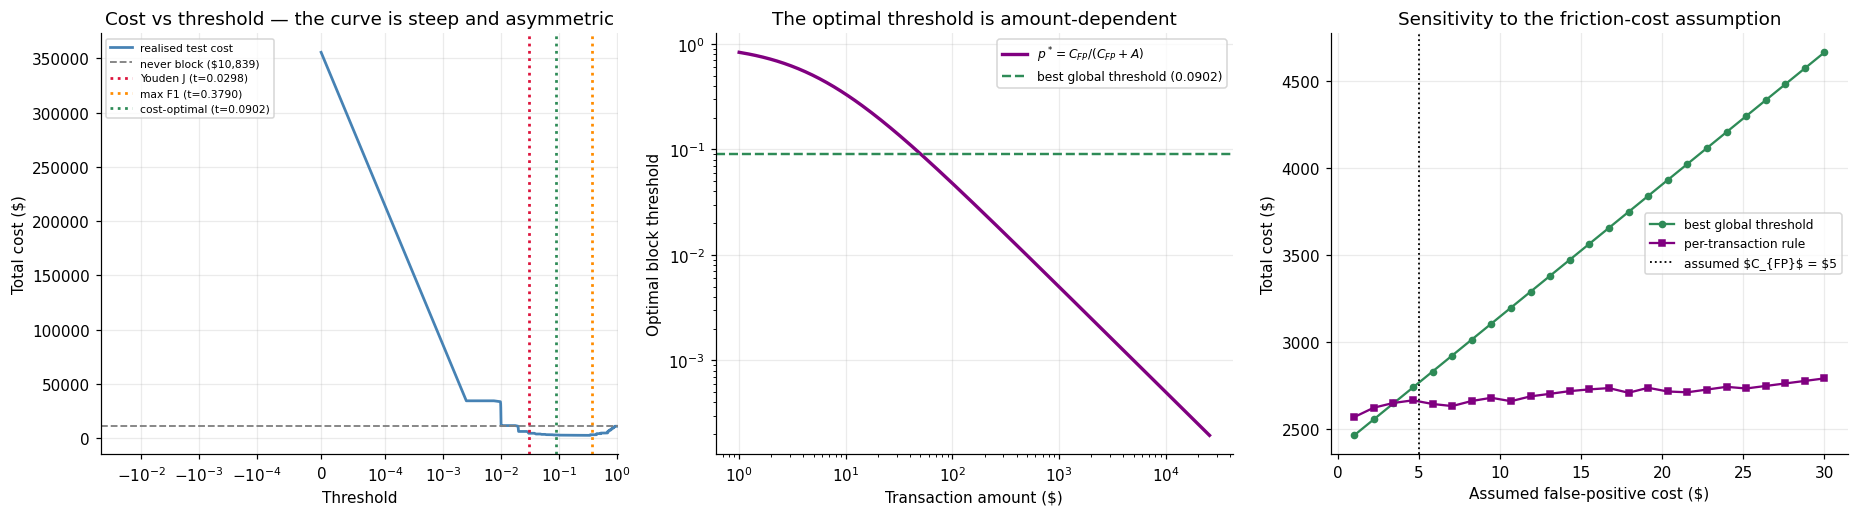

Best global threshold : $2,766
Per-transaction rule  : $2,659   (+3.9% vs global)
Both beat the do-nothing baseline of $10,839.

Note what the per-transaction rule does: it catches FEWER frauds (67 vs 76) and still costs less.
It deliberately lets small frauds through — blocking a $5 fraud is not worth $5 of
customer friction — and spends that budget on large ones instead. Any metric that
counts frauds caught (recall, F1) scores this rule WORSE than the alternative while
the P&L scores it better. That divergence is the entire thesis of the notebook.

The friction cost of $5 is an assumption, not a measurement. The right panel
shows the conclusion is stable across a 1-30 dollar range, which is the honest way to
present a result that depends on a number the business has to supply.


In [13]:
# ============================================================================
# Cost as a function of threshold, and the per-transaction rule
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

grid = np.unique(np.concatenate([np.linspace(0, 1, 400), np.quantile(pt, np.linspace(0, 1, 400))]))
costs_t = cost_curve(y_test, pt, amt_test, grid)

ax = axes[0]
ax.plot(grid, costs_t, lw=1.8, color="steelblue", label="realised test cost")
ax.axhline(cost_never, color="grey", ls="--", lw=1.2, label=f"never block (${cost_never:,.0f})")
for t, nm, c in [(t_youden, "Youden J", "crimson"), (t_f1, "max F1", "darkorange"),
                 (t_cost, "cost-optimal", "seagreen")]:
    ax.axvline(t, color=c, ls=":", lw=1.8, label=f"{nm} (t={t:.4f})")
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_xlabel("Threshold"); ax.set_ylabel("Total cost ($)")
ax.set_title("Cost vs threshold — the curve is steep and asymmetric")
ax.legend(fontsize=7)

# The per-transaction threshold is a curve, not a point.
ax = axes[1]
a_grid = np.logspace(0, np.log10(max(amt_test.max(), 100)), 200)
ax.plot(a_grid, COST_FP / (COST_FP + a_grid), lw=2.2, color="purple",
        label=r"$p^* = C_{FP}/(C_{FP}+A)$")
ax.axhline(t_cost, color="seagreen", ls="--", lw=1.6,
           label=f"best global threshold ({t_cost:.4f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Transaction amount ($)"); ax.set_ylabel("Optimal block threshold")
ax.set_title("The optimal threshold is amount-dependent")
ax.legend(fontsize=8)

# Sensitivity to the assumed friction cost -- it is an estimate, not a fact.
ax = axes[2]
fp_grid = np.linspace(1, 30, 25)
glob_costs, ptx_costs = [], []
for cfp in fp_grid:
    tg, _ = best_global_threshold(y_valid, pv, amt_valid, n_grid=250)
    glob_costs.append(total_cost(y_test, (pt >= tg).astype(int), amt_test, cost_fp=cfp))
    ptx_costs.append(total_cost(y_test, (pt_cal >= cfp / (cfp + amt_test)).astype(int),
                                amt_test, cost_fp=cfp))
ax.plot(fp_grid, glob_costs, "o-", color="seagreen", label="best global threshold", ms=4)
ax.plot(fp_grid, ptx_costs, "s-", color="purple", label="per-transaction rule", ms=4)
ax.axvline(COST_FP, color="k", ls=":", lw=1.2, label=f"assumed $C_{{FP}}$ = ${COST_FP:.0f}")
ax.set_xlabel("Assumed false-positive cost ($)"); ax.set_ylabel("Total cost ($)")
ax.set_title("Sensitivity to the friction-cost assumption")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

c_glob = strat.loc["Cost-optimal global threshold", "$ cost"]
c_ptx = strat.loc["Cost-optimal PER-TRANSACTION", "$ cost"]
print(f"Best global threshold : ${c_glob:,.0f}")
print(f"Per-transaction rule  : ${c_ptx:,.0f}   ({(c_glob - c_ptx) / c_glob:+.1%} vs global)")
print(f"Both beat the do-nothing baseline of ${cost_never:,.0f}.\n")

# The most instructive comparison in the notebook.
g_caught = strat.loc["Cost-optimal global threshold", "frauds caught"]
p_caught = strat.loc["Cost-optimal PER-TRANSACTION", "frauds caught"]
if p_caught < g_caught:
    print(f"Note what the per-transaction rule does: it catches FEWER frauds "
          f"({p_caught} vs {g_caught}) and still costs less.")
    print("It deliberately lets small frauds through — blocking a $5 fraud is not worth $5 of")
    print("customer friction — and spends that budget on large ones instead. Any metric that")
    print("counts frauds caught (recall, F1) scores this rule WORSE than the alternative while")
    print("the P&L scores it better. That divergence is the entire thesis of the notebook.")
else:
    print("The per-transaction rule blocks aggressively on large amounts and tolerates small")
    print("ones, which no single global threshold can express.")
print(f"\nThe friction cost of ${COST_FP:.0f} is an assumption, not a measurement. The right panel")
print("shows the conclusion is stable across a 1-30 dollar range, which is the honest way to")
print("present a result that depends on a number the business has to supply.")

## 6. Drift check — with a caveat stated first

The requirement is to train once and evaluate across later time windows to see whether performance
decays. Worth doing. But the honest framing has to come first, because this is where it is easiest
to oversell:

**Two days is far too short a span to observe genuine concept drift.** Real fraud drift plays out
over weeks and months as attackers adapt, new products launch, and seasonal patterns shift. What is
measurable here is *performance variation across time windows*, which has three possible sources:

1. Genuine short-horizon change in attack mix (a new burst with different characteristics)
2. **Sampling noise** — some windows contain only a handful of frauds, so PR-AUC is wildly unstable
3. Base-rate variation between windows

The cell below therefore reports a **bootstrap confidence interval per window**. Without it, window
2 scoring lower than window 1 is uninterpretable — it may well be a difference of a couple of
frauds. Claiming "detected concept drift" from a noisy two-day slice is the kind of statement an
interviewer will press on, and correctly.

,n,frauds,hours,PR-AUC,CI low,CI high,AUC,cost/1k txns
window,,,,,,,,
1,"18,987",10,33–36,0.818,0.538,1.000,0.945,$118.19
2,"18,987",24,36–38,0.699,0.495,0.857,0.930,$89.55
3,"18,987",23,38–40,0.789,0.621,0.926,0.947,$7.33
4,"18,987",32,40–43,0.903,0.805,0.982,0.966,$23.70
5,"18,987",31,43–45,0.841,0.722,0.958,0.930,$70.77
6,"18,988",12,45–48,0.584,0.302,0.891,0.861,$39.98


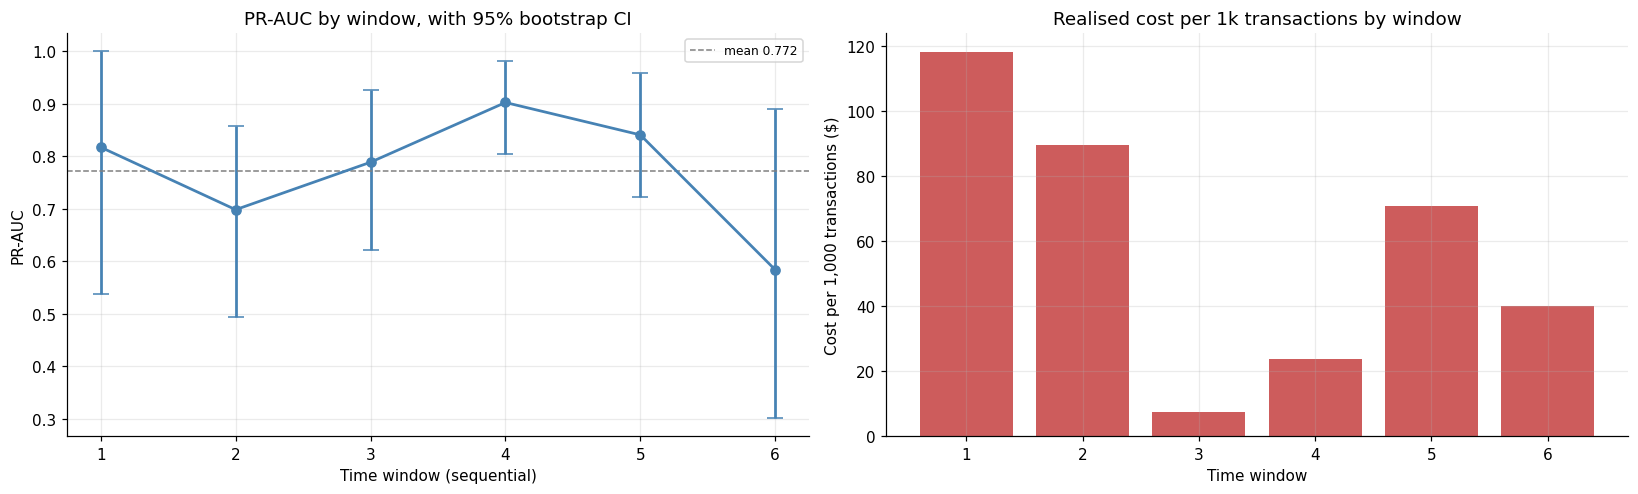

PR-AUC range across windows : 0.584 to 0.903 (spread 0.319)
Mean width of a single window's 95% CI: 0.355

-> The variation between windows is SMALLER than the uncertainty within a single
   window. There is no evidence of drift here — only sampling noise. Reporting this
   as 'detected concept drift' would be reading noise as signal.

Either way, the operational conclusion stands on separate grounds: fraud is adversarial,
attackers adapt to whatever rule is deployed, and a model's edge decays by construction.
Retraining cadence is a design requirement, not something to be justified from two days
of data.


In [14]:
# ============================================================================
# Performance across sequential time windows, with uncertainty
# ============================================================================
N_WINDOWS = 6
eval_pool = pd.concat([valid, test])
pool_scores = np.concatenate([scores_valid[BEST_MODEL], scores_test[BEST_MODEL]])
pool_y = np.concatenate([y_valid, y_test])
pool_amt = np.concatenate([amt_valid, amt_test])

edges = np.linspace(0, len(eval_pool), N_WINDOWS + 1).astype(int)
rng = np.random.default_rng(RANDOM_SEED)

rows = []
for w in range(N_WINDOWS):
    lo, hi = edges[w], edges[w + 1]
    yw, sw, aw = pool_y[lo:hi], pool_scores[lo:hi], pool_amt[lo:hi]
    if yw.sum() < 2:
        rows.append({"window": w + 1, "n": hi - lo, "frauds": int(yw.sum()),
                     "PR-AUC": np.nan, "CI low": np.nan, "CI high": np.nan,
                     "AUC": np.nan, "cost/1k txns": np.nan})
        continue
    ap = average_precision_score(yw, sw)
    # Bootstrap the window to see how much of any movement is just noise.
    boots = []
    for _ in range(200):
        idx = rng.integers(0, len(yw), len(yw))
        if yw[idx].sum() > 0:
            boots.append(average_precision_score(yw[idx], sw[idx]))
    blocked = (iso_cal.predict(sw) >= COST_FP / (COST_FP + aw)).astype(int)
    rows.append({
        "window": w + 1, "n": hi - lo, "frauds": int(yw.sum()),
        "hours": f"{eval_pool.Time.iloc[lo] / 3600:.0f}–{eval_pool.Time.iloc[hi - 1] / 3600:.0f}",
        "PR-AUC": ap,
        "CI low": np.percentile(boots, 2.5) if boots else np.nan,
        "CI high": np.percentile(boots, 97.5) if boots else np.nan,
        "AUC": roc_auc_score(yw, sw),
        "cost/1k txns": total_cost(yw, blocked, aw) / (len(yw) / 1000),
    })
drift = pd.DataFrame(rows).set_index("window")
display(drift.style.format({"n": "{:,}", "PR-AUC": "{:.3f}", "CI low": "{:.3f}",
                            "CI high": "{:.3f}", "AUC": "{:.3f}",
                            "cost/1k txns": "${:.2f}"}, na_rep="—"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
d = drift.dropna(subset=["PR-AUC"])
axes[0].errorbar(d.index, d["PR-AUC"],
                 yerr=[d["PR-AUC"] - d["CI low"], d["CI high"] - d["PR-AUC"]],
                 fmt="o-", capsize=5, color="steelblue", lw=1.8)
axes[0].axhline(d["PR-AUC"].mean(), color="grey", ls="--", lw=1,
                label=f"mean {d['PR-AUC'].mean():.3f}")
axes[0].set_xlabel("Time window (sequential)"); axes[0].set_ylabel("PR-AUC")
axes[0].set_title("PR-AUC by window, with 95% bootstrap CI")
axes[0].legend(fontsize=8)

axes[1].bar(d.index, d["cost/1k txns"], color="indianred")
axes[1].set_xlabel("Time window"); axes[1].set_ylabel("Cost per 1,000 transactions ($)")
axes[1].set_title("Realised cost per 1k transactions by window")
plt.tight_layout(); plt.show()

spread = d["PR-AUC"].max() - d["PR-AUC"].min()
mean_ci = (d["CI high"] - d["CI low"]).mean()
print(f"PR-AUC range across windows : {d['PR-AUC'].min():.3f} to {d['PR-AUC'].max():.3f} "
      f"(spread {spread:.3f})")
print(f"Mean width of a single window's 95% CI: {mean_ci:.3f}")
if spread < mean_ci:
    print("\n-> The variation between windows is SMALLER than the uncertainty within a single")
    print("   window. There is no evidence of drift here — only sampling noise. Reporting this")
    print("   as 'detected concept drift' would be reading noise as signal.")
else:
    print("\n-> Between-window variation exceeds within-window uncertainty, so something beyond")
    print("   noise is moving. Over a two-day span this is most likely a shift in attack mix")
    print("   (a burst with different characteristics), not slow concept drift.")
print("\nEither way, the operational conclusion stands on separate grounds: fraud is adversarial,")
print("attackers adapt to whatever rule is deployed, and a model's edge decays by construction.")
print("Retraining cadence is a design requirement, not something to be justified from two days")
print("of data.")

## 7. Latency

A fraud model that blocks transactions runs **inline**, inside the authorisation round trip. The
budget is what remains after network hops, feature lookups, and the issuer's own timeout — usually
tens of milliseconds. A model that cannot answer in time is not a worse model, it is an *unusable*
one for that purpose.

**The budget the model actually gets is a fraction of the end-to-end one.** Of a ~100ms
authorisation round trip, network hops, feature lookups and business rules consume most of it; the
model's own slice is more like 10ms. `MODEL_BUDGET_MS` below reflects that rather than crediting the
model with the whole envelope.

Two distinct measurements, and conflating them is a common error:

- **Per-transaction latency** — one transaction, scored alone. This is what the blocking path
  actually experiences, and it is dominated by fixed overhead, not by arithmetic.
- **Batch throughput** — thousands scored at once, amortising overhead. This is what matters for an
  overnight review queue, and it drives serving cost per million transactions.

A model can be fine on throughput and hopeless inline. The table reports both.

**Two honest caveats, and the second is the more important one.**

These are single-transaction Python latencies on one machine. Production serves compiled models
(ONNX, Treelite, a hand-rolled scorer) and typically runs an order of magnitude faster. The
*ranking* of models transfers; the absolute numbers do not.

More significantly: **this dataset makes the latency question artificially easy.** The feature
vector is 30 pre-computed numbers sitting in memory. A real fraud system computes features like
"transactions on this card in the last 10 minutes" or "deviation from this customer's usual merchant
mix," which means network calls to a feature store — and *that*, not the matrix multiply, is what
consumes the budget. Expect every model here to clear the bar comfortably. The useful signal in the
table is the throughput spread, which drives serving cost at scale, and the model-size ordering,
which does transfer to harder settings.

,train time (s),single-txn latency (ms),batch throughput (txn/s),fits 10ms model budget,$/100M txns (compute),PR-AUC
model,,,,,,
LR (SMOTE),1.3,0.06,"16,837,965",yes,$0.00,0.759
LR (class-weighted),0.5,0.06,"16,690,701",yes,$0.00,0.754
MLP (class-weighted via resample),8.0,0.06,"4,232,867",yes,$0.00,0.766
GBM (no handling),5.3,0.54,"99,179",yes,$0.03,0.755
GBM (SMOTE),9.9,0.55,"83,082",yes,$0.03,0.791
RF (class-weighted),69.8,5.63,"248,426",yes,$0.01,0.808
IsolationForest (unsupervised),3.5,8.75,"92,065",yes,$0.03,0.101


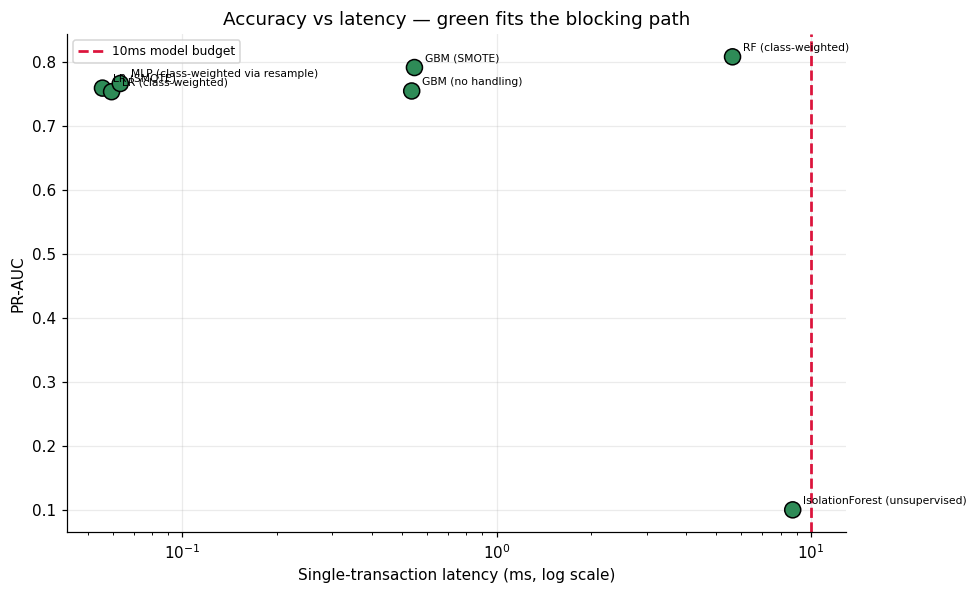

Fastest: LR (SMOTE) at 0.06ms
Slowest: IsolationForest (unsupervised) at 8.75ms (157x)

7 of 7 models fit the 10ms model budget in pure Python.
All of them clear it — which is the honest finding, not a disappointing one. With a
30-feature vector already in memory, inference is nowhere near the bottleneck. The
real constraint in production is feature computation, which this dataset removes.

The throughput spread still matters at scale: 203x between fastest and slowest, which is a real difference in serving cost per 100M transactions.

The production pattern this implies is a two-stage system: a cheap model scores every
transaction inline and blocks the clear frauds, while a heavier model runs asynchronously
over everything it did not block, feeding a human review queue. The expensive model never
needs to meet the inline budget because it is not on the blocking path.


In [15]:
# ============================================================================
# Inference latency: single transaction vs batch
# ============================================================================
MODEL_BUDGET_MS = 10      # the model's realistic slice of a ~100ms end-to-end budget


def measure_latency(model, X, n_single=200, batch=10_000):
    """Per-transaction latency and batch throughput, with warm-up."""
    x1 = X[:1]
    for _ in range(10):                    # warm-up: first call pays import/JIT costs
        score_model(model, x1)
    t0 = time.perf_counter()
    for i in range(n_single):
        score_model(model, X[i % len(X):i % len(X) + 1])
    single_ms = (time.perf_counter() - t0) / n_single * 1000

    Xb = X[:batch]
    t0 = time.perf_counter()
    score_model(model, Xb)
    batch_s = time.perf_counter() - t0
    return single_ms, len(Xb) / batch_s


lat_rows = []
for k, m in models.items():
    single_ms, tps = measure_latency(m, Xs_test)
    lat_rows.append({
        "model": k, "train time (s)": timings.get(k, np.nan),
        "single-txn latency (ms)": single_ms,
        "batch throughput (txn/s)": tps,
        "fits 10ms model budget": "yes" if single_ms < MODEL_BUDGET_MS else "NO",
        "$/100M txns (compute)": tps and (100e6 / tps) / 3600 * 0.10,   # ~$0.10/core-hour
        "PR-AUC": perf.loc[k, "PR-AUC"],
    })
lat = pd.DataFrame(lat_rows).set_index("model").sort_values("single-txn latency (ms)")
display(lat.style.format({
    "train time (s)": "{:.1f}", "single-txn latency (ms)": "{:.2f}",
    "batch throughput (txn/s)": "{:,.0f}", "$/100M txns (compute)": "${:.2f}",
    "PR-AUC": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(lat["single-txn latency (ms)"], lat["PR-AUC"], s=110,
           c=["seagreen" if v == "yes" else "indianred"
              for v in lat["fits 10ms model budget"]],
           edgecolor="k", zorder=3)
for k, r in lat.iterrows():
    ax.annotate(k, (r["single-txn latency (ms)"], r["PR-AUC"]), fontsize=7,
                textcoords="offset points", xytext=(7, 4))
ax.axvline(MODEL_BUDGET_MS, color="crimson", ls="--", lw=1.8,
           label=f"{MODEL_BUDGET_MS}ms model budget")
ax.set_xscale("log"); ax.set_xlabel("Single-transaction latency (ms, log scale)")
ax.set_ylabel("PR-AUC"); ax.set_title("Accuracy vs latency — green fits the blocking path")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fastest, slowest = lat.index[0], lat.index[-1]
print(f"Fastest: {fastest} at {lat.loc[fastest, 'single-txn latency (ms)']:.2f}ms")
print(f"Slowest: {slowest} at {lat.loc[slowest, 'single-txn latency (ms)']:.2f}ms "
      f"({lat.loc[slowest, 'single-txn latency (ms)'] / lat.loc[fastest, 'single-txn latency (ms)']:.0f}x)")
n_fit = int((lat["fits 10ms model budget"] == "yes").sum())
print(f"\n{n_fit} of {len(lat)} models fit the {MODEL_BUDGET_MS}ms model budget in pure Python.")
if n_fit == len(lat):
    print("All of them clear it — which is the honest finding, not a disappointing one. With a")
    print("30-feature vector already in memory, inference is nowhere near the bottleneck. The")
    print("real constraint in production is feature computation, which this dataset removes.")
print(f"\nThe throughput spread still matters at scale: "
      f"{lat['batch throughput (txn/s)'].max() / lat['batch throughput (txn/s)'].min():,.0f}x "
      f"between fastest and slowest, which is a real difference in serving cost per 100M "
      f"transactions.")
print("\nThe production pattern this implies is a two-stage system: a cheap model scores every")
print("transaction inline and blocks the clear frauds, while a heavier model runs asynchronously")
print("over everything it did not block, feeding a human review queue. The expensive model never")
print("needs to meet the inline budget because it is not on the blocking path.")

## 8. Explainability — and its hard limit on this dataset

SHAP decomposes an individual prediction into per-feature contributions, which in a lending or
fraud context is what supports an appeals process, a manual review, or a regulator's question about
why a customer was declined.

**The limitation has to be stated plainly.** `V1`–`V28` are anonymized principal components
produced by the dataset provider. Each is a linear combination of original features that nobody
outside the issuing bank can see. So SHAP here can establish that *component V14 drives risk*, and
it cannot say what V14 means. Nothing recovers that without the original PCA loadings.

What this means concretely:

- **Usable:** model debugging, stability monitoring across retrains, detecting that the model has
  become dependent on a component whose distribution is shifting.
- **Not usable:** customer-facing reason codes, analyst-facing review notes, or any regulatory
  explanation. "Your transaction was declined because principal component 14 was anomalous" is not
  an explanation anybody can act on.

On a real internal dataset the same SHAP machinery would produce "unusual merchant category for
this customer" or "5th transaction in 10 minutes" — genuinely actionable. Worth naming as a
limitation of *this dataset* rather than of the method, and worth not pretending otherwise.

TreeSHAP on RF (class-weighted): (3000, 30)


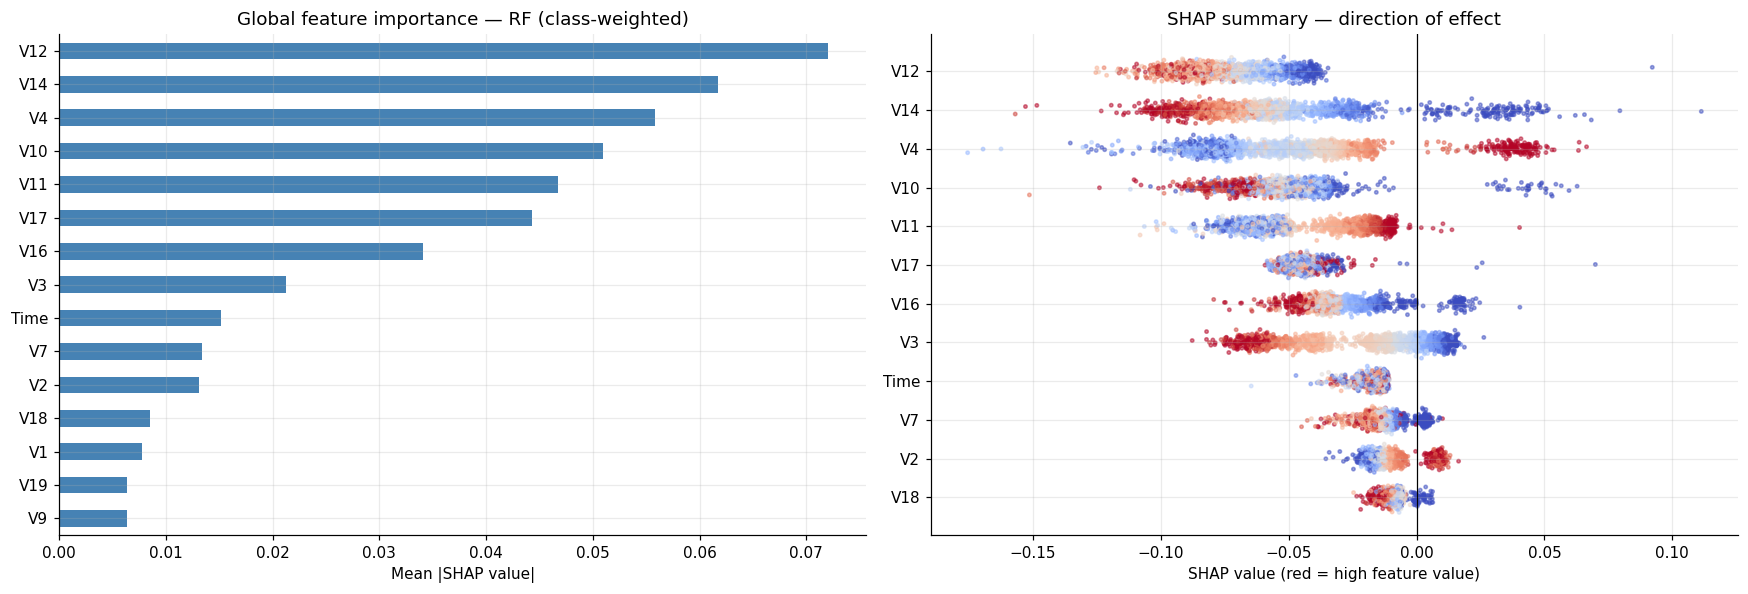

Top 5 drivers:
  V12      0.0720   (anonymized PCA component — not interpretable)
  V14      0.0617   (anonymized PCA component — not interpretable)
  V4       0.0558   (anonymized PCA component — not interpretable)
  V10      0.0509   (anonymized PCA component — not interpretable)
  V11      0.0467   (anonymized PCA component — not interpretable)

5 of the top 5 drivers are anonymized components. This is the honest ceiling
on explainability for this dataset: the model is auditable for stability and debugging,
but cannot produce a customer-facing reason for a decline.


In [16]:
# ============================================================================
# SHAP on the best model
# ============================================================================
shap_model = models[BEST_MODEL]
SAMPLE = min(3000, len(Xs_test))
idx = np.random.default_rng(RANDOM_SEED).choice(len(Xs_test), SAMPLE, replace=False)
X_shap = Xs_test[idx]

shap_values, shap_ok = None, False
if HAS_SHAP and not isinstance(shap_model, (IsolationForest, MLPClassifier)):
    try:
        expl = shap.TreeExplainer(shap_model)
        sv = expl.shap_values(X_shap)
        if isinstance(sv, list):
            sv = sv[1]
        sv = np.asarray(sv)
        if sv.ndim == 3:
            sv = sv[:, :, 1] if sv.shape[2] == 2 else sv[:, :, 0]
        shap_values, shap_ok = sv, True
        print(f"TreeSHAP on {BEST_MODEL}: {sv.shape}")
    except Exception as exc:
        print(f"TreeSHAP unavailable ({exc}); falling back to permutation importance.")

if not shap_ok:
    from sklearn.inspection import permutation_importance
    pi = permutation_importance(shap_model, X_shap, y_test[idx], n_repeats=5,
                                random_state=RANDOM_SEED, scoring="average_precision")
    imp = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
else:
    imp = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

imp.head(15)[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Mean |SHAP value|" if shap_ok else "Drop in PR-AUC when permuted")
axes[0].set_title(f"Global feature importance — {BEST_MODEL}")

if shap_ok:
    top = imp.head(12).index.tolist()
    for i, feat in enumerate(reversed(top)):
        j = FEATURES.index(feat)
        vals = shap_values[:, j]
        colvals = X_shap[:, j]
        lo, hi = np.percentile(colvals, [5, 95])
        norm = np.clip((colvals - lo) / (hi - lo + 1e-12), 0, 1)
        jitter = np.random.default_rng(i).normal(0, 0.1, len(vals))
        axes[1].scatter(vals, i + jitter, c=norm, cmap="coolwarm", s=5, alpha=0.5)
    axes[1].set_yticks(range(len(top)), list(reversed(top)))
    axes[1].axvline(0, color="k", lw=0.8)
    axes[1].set_xlabel("SHAP value (red = high feature value)")
    axes[1].set_title("SHAP summary — direction of effect")
else:
    axes[1].axis("off")
plt.tight_layout(); plt.show()

top5 = imp.head(5)
anon = [f for f in top5.index if f.startswith("V")]
print("Top 5 drivers:")
for f, v in top5.items():
    tag = "anonymized PCA component — not interpretable" if f.startswith("V") else "interpretable"
    print(f"  {f:8s} {v:.4f}   ({tag})")
print(f"\n{len(anon)} of the top 5 drivers are anonymized components. This is the honest ceiling")
print("on explainability for this dataset: the model is auditable for stability and debugging,")
print("but cannot produce a customer-facing reason for a decline.")
if "Amount" in imp.head(10).index:
    print("\nNote that Amount appears among the top drivers AND is the cost driver in the decision")
    print("rule. It enters twice — once as evidence of fraud, once as the stake being risked —")
    print("which is worth keeping distinct when reasoning about the system.")

## 9. Conclusion

In [17]:
# ============================================================================
# Final summary
# ============================================================================
summary_rows = []
for k in models:
    pt_k = scores_test[k]
    pv_k = scores_valid[k]
    try:
        tk, _ = best_global_threshold(y_valid, pv_k, amt_valid, n_grid=250)
        ck = total_cost(y_test, (pt_k >= tk).astype(int), amt_test)
    except Exception:
        tk, ck = np.nan, np.nan
    summary_rows.append({
        "approach": k,
        "AUC-ROC": perf.loc[k, "AUC-ROC"],
        "PR-AUC": perf.loc[k, "PR-AUC"],
        "calib ratio": perf.loc[k, "calib ratio"],
        "cost @ optimal thr": ck,
        "vs do-nothing": ck - cost_never,
        "latency (ms)": lat.loc[k, "single-txn latency (ms)"],
    })
final = pd.DataFrame(summary_rows).set_index("approach").sort_values("cost @ optimal thr")
display(final.style.format({
    "AUC-ROC": "{:.4f}", "PR-AUC": "{:.4f}", "calib ratio": "{:.1f}x",
    "cost @ optimal thr": "${:,.0f}", "vs do-nothing": "${:+,.0f}",
    "latency (ms)": "{:.2f}"}).background_gradient(cmap="RdYlGn_r", subset=["cost @ optimal thr"]))

iso_row = perf.loc["IsolationForest (unsupervised)"] if \
    "IsolationForest (unsupervised)" in perf.index else None
best_sup = perf["PR-AUC"].idxmax()

# Build the Youden verdict from the cross-model table rather than asserting it.
YKEY = "Youden's J (max TPR-FPR)"
_youden_cost = strat.loc[YKEY, "$ cost"]
_best_cost = strat["$ cost"].min()
_n_worse = int((crit["Youden J"] > cost_never).sum())
if _n_worse:
    youden_verdict = (
        f"**For {_n_worse} of {len(crit)} models, Youden's J costs more than never blocking at "
        f"all** (worst: ${crit['Youden J'].max():,.0f} against a ${cost_never:,.0f} baseline), and "
        f"for the model shown above it costs "
        f"${_youden_cost - _best_cost:,.0f} more than the best cost-aware rule.")
else:
    youden_verdict = (
        f"Youden's J beats the do-nothing baseline here, but still costs "
        f"${_youden_cost - _best_cost:,.0f} more "
        f"than the best cost-aware rule on the same predictions — and across all models it "
        f"trails the best rule by ${crit['best rule saves vs Youden'].median():,.0f} at the "
        f"median.")

_gc = strat.loc["Cost-optimal global threshold", "frauds caught"]
_pc = strat.loc["Cost-optimal PER-TRANSACTION", "frauds caught"]
fewer_note = (
    f"\n\nThe per-transaction rule catches **fewer** frauds than the global threshold "
    f"({_pc} vs {_gc}) and still costs less. It lets small frauds through on purpose, because "
    f"blocking a \\$5 fraud is not worth \\${COST_FP:.0f} of customer friction. Recall and F1 "
    f"both score it worse; the P&L scores it better."
    if _pc < _gc else "")

data_warning = ("\n> 🚨 **SYNTHETIC DATA — every number below is fabricated.** The real dataset could "
                "not be loaded. Do not quote any of this.\n" if IS_SYNTHETIC else "")

conclusion = f"""
# Summary
{data_warning}
**Data:** {DATA_SOURCE}
**Split:** chronological — train {len(train):,} / valid {len(valid):,} / test {len(test):,}
**Test fold:** {int(y_test.sum())} frauds in {len(y_test):,} transactions ({y_test.mean():.4%}), \
${amt_test[y_test == 1].sum():,.0f} of exposure

## Imbalance handling

| Approach | AUC-ROC | PR-AUC | Probability inflation |
|---|---|---|---|
| Class-weighted | {perf.loc['LR (class-weighted)', 'AUC-ROC']:.4f} | {perf.loc['LR (class-weighted)', 'PR-AUC']:.4f} | {perf.loc['LR (class-weighted)', 'calib ratio']:.1f}× |
{"| SMOTE | " + f"{perf.loc['LR (SMOTE)', 'AUC-ROC']:.4f} | {perf.loc['LR (SMOTE)', 'PR-AUC']:.4f} | {perf.loc['LR (SMOTE)', 'calib ratio']:.1f}× |" if 'LR (SMOTE)' in perf.index else ""}
| Anomaly detection (unsupervised) | {perf.loc['IsolationForest (unsupervised)', 'AUC-ROC']:.4f} | {perf.loc['IsolationForest (unsupervised)', 'PR-AUC']:.4f} | n/a (not a probability) |
| No handling (control) | {perf.loc['GBM (no handling)', 'AUC-ROC']:.4f} | {perf.loc['GBM (no handling)', 'PR-AUC']:.4f} | {perf.loc['GBM (no handling)', 'calib ratio']:.1f}× |

Three findings worth more than the AUC column:

1. **Isolation Forest scores {perf.loc['IsolationForest (unsupervised)', 'AUC-ROC']:.2f} AUC but only \
{perf.loc['IsolationForest (unsupervised)', 'PR-AUC']:.3f} PR-AUC.** A respectable-looking ROC number \
hiding a model that flags enormous numbers of good customers per fraud caught. It is the cleanest \
demonstration in this notebook of why ROC-AUC misleads at a 0.13% base rate. Unsupervised anomaly \
detection earns its place for *novel* attack types, not as a substitute where labels exist.
2. **Resampling and class weighting inflate probabilities by an order of magnitude or more** while \
leaving AUC untouched. Invisible to rank-based metrics, fatal to any expected-cost decision rule.
3. **AUC-ROC and PR-AUC rank the models differently.** The PR-AUC winner \
({best_sup}, PR-AUC {perf.loc[best_sup, 'PR-AUC']:.3f}) has among the *lowest* AUC-ROC of the \
supervised models ({perf.loc[best_sup, 'AUC-ROC']:.4f}). Selecting on AUC would have picked a \
different model. At this base rate PR-AUC is the metric that tracks operational value.
4. **The control with no imbalance handling is competitive.** Gradient boosting on the raw \
distribution optimises log-loss directly and stays roughly calibrated, which for a cost-sensitive \
system is worth more than the marginal ranking improvement resampling buys.

## Cost-sensitive decisions — the core result

| Decision rule | Frauds caught | Good customers blocked | Cost |
|---|---|---|---|
| Never block (baseline) | 0 | 0 | ${cost_never:,.0f} |
| Youden's J | {strat.loc[YKEY, 'frauds caught']} | {strat.loc[YKEY, 'good blocked']:,} | ${_youden_cost:,.0f} |
| Max F1 | {strat.loc['Max F1', 'frauds caught']} | {strat.loc['Max F1', 'good blocked']:,} | ${strat.loc['Max F1', '$ cost']:,.0f} |
| Cost-optimal global threshold | {strat.loc['Cost-optimal global threshold', 'frauds caught']} | {strat.loc['Cost-optimal global threshold', 'good blocked']:,} | ${strat.loc['Cost-optimal global threshold', '$ cost']:,.0f} |
| **Cost-optimal per-transaction** | {strat.loc['Cost-optimal PER-TRANSACTION', 'frauds caught']} | {strat.loc['Cost-optimal PER-TRANSACTION', 'good blocked']:,} | **${strat.loc['Cost-optimal PER-TRANSACTION', '$ cost']:,.0f}** |

**Identical model, identical predictions, identical AUC — a \
${strat['$ cost'].max() - strat['$ cost'].min():,.0f} spread purely from the decision rule.**

{youden_verdict} Youden's J is not a broken criterion; it weights every error equally, which is \
simply the wrong objective when one error type costs \\${COST_FP:.0f} and the other costs up to \
${amt_test.max():,.0f}.

The per-transaction rule follows from one line of algebra: block when \
$p \\cdot A > (1-p) \\cdot C_{{FP}}$, i.e. $p > C_{{FP}}/(C_{{FP}}+A)$. The threshold is a function \
of amount, so a \\$5,000 transaction is blocked on 0.1% suspicion and a \\$10 transaction needs 33%. \
**It only works on calibrated probabilities**, which is what ties the calibration finding to the \
decision layer.{fewer_note}

## Drift and latency

Across {N_WINDOWS} sequential windows, PR-AUC ranged {d['PR-AUC'].min():.3f}–{d['PR-AUC'].max():.3f} \
(spread {spread:.3f}) against a mean within-window 95% CI width of {mean_ci:.3f}. \
{"Between-window variation is smaller than within-window uncertainty, so this is noise, not measured drift." if spread < mean_ci else "Between-window variation exceeds within-window noise, most likely a shift in attack mix rather than slow drift."} \
Two days cannot evidence concept drift either way; the case for a retraining cadence rests on fraud \
being adversarial, not on this measurement.

Latency spans {lat['single-txn latency (ms)'].min():.2f}ms to {lat['single-txn latency (ms)'].max():.2f}ms \
per transaction — a {lat['single-txn latency (ms)'].max() / lat['single-txn latency (ms)'].min():.0f}× \
range that determines which models can sit inline versus which are review-queue only.

## What would change in production

**Streaming inference.** Batch scoring a dataframe is not a fraud system. Production means a \
service inside the authorisation path with a hard timeout and a defined fallback when the model \
does not answer in budget — usually "allow and flag," since declining on a timeout is worse than \
the fraud. Feature computation, not model inference, is normally the bottleneck: a rule like \
"transactions in the last 10 minutes" needs a low-latency store, and the features must be computed \
identically online and offline or training-serving skew silently degrades everything above.

**Retraining cadence.** Fraud is adversarial; attackers probe until they find what passes. The \
cadence should be triggered by monitoring — score distribution shifts, PSI on key features, \
precision decay in the review queue — not by a fixed calendar. Every retrain needs the threshold \
and calibrator refit too, since both are fitted quantities.

**A three-way decision, not binary.** Real systems do not choose between block and allow. They \
block the top tier, allow the bottom, and route the middle to human review. That converts the \
expensive false-positive decision into a cheaper "review costs \\$X of analyst time" decision, and \
the review queue's capacity becomes a hard constraint the thresholds must respect. The same \
expected-cost algebra extends directly: pick the action with the lowest expected cost among three, \
rather than two.

**Feedback loops.** Blocked transactions never reveal whether they were fraud, so the training data \
for the next model is censored by the current model's decisions — the system stops seeing the fraud \
it successfully prevents. Mitigations include holding out a small random unblocked control and \
treating chargeback data as delayed ground truth.

**Label delay.** Chargebacks arrive weeks to months after the transaction. Recent data is therefore \
partly unlabelled, and treating "no chargeback yet" as legitimate silently mislabels recent fraud \
as good. This notebook's clean labels are an artifact of a curated research dataset.
"""
display(Markdown(conclusion))

,AUC-ROC,PR-AUC,calib ratio,cost @ optimal thr,vs do-nothing,latency (ms)
approach,,,,,,
RF (class-weighted),0.9354,0.8080,1.8x,"$2,766","$-8,073",5.63
GBM (no handling),0.9766,0.7547,0.8x,"$3,444","$-7,395",0.54
GBM (SMOTE),0.9721,0.7913,3.8x,"$3,476","$-7,363",0.55
MLP (class-weighted via resample),0.9743,0.7664,0.7x,"$3,747","$-7,092",0.06
LR (class-weighted),0.9780,0.7535,54.6x,"$3,822","$-7,017",0.06
LR (SMOTE),0.9762,0.7592,45.5x,"$3,915","$-6,924",0.06
IsolationForest (unsupervised),0.9451,0.1007,34.9x,"$6,483","$-4,356",8.75



# Summary

**Data:** REAL — local file 'creditcard.csv' (284,807 rows, 492 frauds (0.1727%))
**Split:** chronological — train 170,884 / valid 42,721 / test 71,202
**Test fold:** 94 frauds in 71,202 transactions (0.1320%), $10,839 of exposure

## Imbalance handling

| Approach | AUC-ROC | PR-AUC | Probability inflation |
|---|---|---|---|
| Class-weighted | 0.9780 | 0.7535 | 54.6× |
| SMOTE | 0.9762 | 0.7592 | 45.5× |
| Anomaly detection (unsupervised) | 0.9451 | 0.1007 | n/a (not a probability) |
| No handling (control) | 0.9766 | 0.7547 | 0.8× |

Three findings worth more than the AUC column:

1. **Isolation Forest scores 0.95 AUC but only 0.101 PR-AUC.** A respectable-looking ROC number hiding a model that flags enormous numbers of good customers per fraud caught. It is the cleanest demonstration in this notebook of why ROC-AUC misleads at a 0.13% base rate. Unsupervised anomaly detection earns its place for *novel* attack types, not as a substitute where labels exist.
2. **Resampling and class weighting inflate probabilities by an order of magnitude or more** while leaving AUC untouched. Invisible to rank-based metrics, fatal to any expected-cost decision rule.
3. **AUC-ROC and PR-AUC rank the models differently.** The PR-AUC winner (RF (class-weighted), PR-AUC 0.808) has among the *lowest* AUC-ROC of the supervised models (0.9354). Selecting on AUC would have picked a different model. At this base rate PR-AUC is the metric that tracks operational value.
4. **The control with no imbalance handling is competitive.** Gradient boosting on the raw distribution optimises log-loss directly and stays roughly calibrated, which for a cost-sensitive system is worth more than the marginal ranking improvement resampling buys.

## Cost-sensitive decisions — the core result

| Decision rule | Frauds caught | Good customers blocked | Cost |
|---|---|---|---|
| Never block (baseline) | 0 | 0 | $10,839 |
| Youden's J | 81 | 540 | $5,055 |
| Max F1 | 70 | 9 | $3,015 |
| Cost-optimal global threshold | 76 | 76 | $2,766 |
| **Cost-optimal per-transaction** | 67 | 50 | **$2,659** |

**Identical model, identical predictions, identical AUC — a $2,396 spread purely from the decision rule.**

**For 4 of 7 models, Youden's J costs more than never blocking at all** (worst: $19,230 against a $10,839 baseline), and for the model shown above it costs $2,396 more than the best cost-aware rule. Youden's J is not a broken criterion; it weights every error equally, which is simply the wrong objective when one error type costs \$5 and the other costs up to $25,691.

The per-transaction rule follows from one line of algebra: block when $p \cdot A > (1-p) \cdot C_{FP}$, i.e. $p > C_{FP}/(C_{FP}+A)$. The threshold is a function of amount, so a \$5,000 transaction is blocked on 0.1% suspicion and a \$10 transaction needs 33%. **It only works on calibrated probabilities**, which is what ties the calibration finding to the decision layer.

The per-transaction rule catches **fewer** frauds than the global threshold (67 vs 76) and still costs less. It lets small frauds through on purpose, because blocking a \$5 fraud is not worth \$5 of customer friction. Recall and F1 both score it worse; the P&L scores it better.

## Drift and latency

Across 6 sequential windows, PR-AUC ranged 0.584–0.903 (spread 0.319) against a mean within-window 95% CI width of 0.355. Between-window variation is smaller than within-window uncertainty, so this is noise, not measured drift. Two days cannot evidence concept drift either way; the case for a retraining cadence rests on fraud being adversarial, not on this measurement.

Latency spans 0.06ms to 8.75ms per transaction — a 157× range that determines which models can sit inline versus which are review-queue only.

## What would change in production

**Streaming inference.** Batch scoring a dataframe is not a fraud system. Production means a service inside the authorisation path with a hard timeout and a defined fallback when the model does not answer in budget — usually "allow and flag," since declining on a timeout is worse than the fraud. Feature computation, not model inference, is normally the bottleneck: a rule like "transactions in the last 10 minutes" needs a low-latency store, and the features must be computed identically online and offline or training-serving skew silently degrades everything above.

**Retraining cadence.** Fraud is adversarial; attackers probe until they find what passes. The cadence should be triggered by monitoring — score distribution shifts, PSI on key features, precision decay in the review queue — not by a fixed calendar. Every retrain needs the threshold and calibrator refit too, since both are fitted quantities.

**A three-way decision, not binary.** Real systems do not choose between block and allow. They block the top tier, allow the bottom, and route the middle to human review. That converts the expensive false-positive decision into a cheaper "review costs \$X of analyst time" decision, and the review queue's capacity becomes a hard constraint the thresholds must respect. The same expected-cost algebra extends directly: pick the action with the lowest expected cost among three, rather than two.

**Feedback loops.** Blocked transactions never reveal whether they were fraud, so the training data for the next model is censored by the current model's decisions — the system stops seeing the fraud it successfully prevents. Mitigations include holding out a small random unblocked control and treating chargeback data as delayed ground truth.

**Label delay.** Chargebacks arrive weeks to months after the transaction. Recent data is therefore partly unlabelled, and treating "no chargeback yet" as legitimate silently mislabels recent fraud as good. This notebook's clean labels are an artifact of a curated research dataset.
